<a href="https://colab.research.google.com/github/dipeshpadole786/CodeSoft-Tasks-DipeshPadole786/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection Project

## 1. Data Loading

In [ ]:
import pandas as pd


try:
    train_df = pd.read_csv('fraudTrain.csv')
    test_df = pd.read_csv('fraudTest.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError:
    print("Error: Make sure 'fraudTrain.csv' and 'fraudTest.csv' are uploaded to your Colab environment.")
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()

Datasets loaded successfully.


### Dataset Shapes

In [ ]:
if not train_df.empty:
    print(f"Shape of fraudTrain.csv: {train_df.shape}")
if not test_df.empty:
    print(f"Shape of fraudTest.csv: {test_df.shape}")

Shape of fraudTrain.csv: (147617, 23)
Shape of fraudTest.csv: (147553, 23)


### Dataset Columns and Data Types (Training Data)

In [ ]:
if not train_df.empty:
    print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147617 entries, 0 to 147616
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             147617 non-null  int64  
 1   trans_date_trans_time  147617 non-null  object 
 2   cc_num                 147617 non-null  int64  
 3   merchant               147617 non-null  object 
 4   category               147617 non-null  object 
 5   amt                    147617 non-null  float64
 6   first                  147617 non-null  object 
 7   last                   147617 non-null  object 
 8   gender                 147617 non-null  object 
 9   street                 147617 non-null  object 
 10  city                   147617 non-null  object 
 11  state                  147617 non-null  object 
 12  zip                    147617 non-null  int64  
 13  lat                    147617 non-null  float64
 14  long                   147617 non-nu

### Sample Records (Training Data)

In [ ]:
if not train_df.empty:
    display(train_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


### Dataset Columns and Data Types (Test Data)

In [ ]:
if not test_df.empty:
    print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147553 entries, 0 to 147552
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             147553 non-null  int64  
 1   trans_date_trans_time  147553 non-null  object 
 2   cc_num                 147553 non-null  int64  
 3   merchant               147553 non-null  object 
 4   category               147553 non-null  object 
 5   amt                    147553 non-null  float64
 6   first                  147553 non-null  object 
 7   last                   147553 non-null  object 
 8   gender                 147553 non-null  object 
 9   street                 147553 non-null  object 
 10  city                   147553 non-null  object 
 11  state                  147553 non-null  object 
 12  zip                    147553 non-null  int64  
 13  lat                    147553 non-null  float64
 14  long                   147552 non-nu

### Sample Records (Test Data)

In [ ]:
if not test_df.empty:
    display(test_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767.0,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


### Check for Missing Values

In [ ]:
print("\nMissing values in Training Data:")
if not train_df.empty:
    display(train_df.isnull().sum()[train_df.isnull().sum() > 0].sort_values(ascending=False))

print("\nMissing values in Test Data:")
if not test_df.empty:
    display(test_df.isnull().sum()[test_df.isnull().sum() > 0].sort_values(ascending=False))


Missing values in Training Data:


,0
dob,1
trans_num,1
unix_time,1
merch_lat,1
merch_long,1
is_fraud,1



Missing values in Test Data:


,0
long,1
city_pop,1
job,1
dob,1
trans_num,1
unix_time,1
merch_lat,1
merch_long,1
is_fraud,1


### Check for Duplicate Rows

In [ ]:
print("\nDuplicate rows in Training Data:")
if not train_df.empty:
    print(f"Number of duplicate rows: {train_df.duplicated().sum()}")

print("\nDuplicate rows in Test Data:")
if not test_df.empty:
    print(f"Number of duplicate rows: {test_df.duplicated().sum()}")


Duplicate rows in Training Data:
Number of duplicate rows: 0

Duplicate rows in Test Data:
Number of duplicate rows: 0


### Dataset Summary (Training Data)

In [ ]:
if not train_df.empty:
    display(train_df.describe())

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,147617.000000,1.476170e+05,147617.000000,147617.000000,147617.000000,147617.000000,1.476170e+05,1.476160e+05,147616.000000,147616.000000,147616.000000
mean,73808.000000,4.164461e+17,71.548564,48767.337610,38.538042,-90.196116,9.006008e+04,1.329029e+09,38.539431,-90.196652,0.009125
std,42613.501681,1.307386e+18,154.210065,26909.405351,5.072235,13.750450,3.041151e+05,2.031807e+06,5.105501,13.762060,0.095088
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.670132,0.000000
25%,36904.000000,1.800365e+14,9.650000,26041.000000,34.620500,-96.798000,7.430000e+02,1.327232e+09,34.739422,-96.888217,0.000000
50%,73808.000000,3.519607e+15,47.760000,48174.000000,39.371600,-87.476900,2.456000e+03,1.329077e+09,39.368665,-87.429431,0.000000
75%,110712.000000,4.642255e+15,83.680000,72011.000000,41.894800,-80.128400,2.112500e+04,1.330844e+09,41.952930,-80.198017,0.000000
max,147616.000000,4.992346e+18,12788.070000,99783.000000,65.689900,-67.950300,2.906700e+06,1.332276e+09,66.659242,-66.967742,1.000000


### Dataset Summary (Test Data)

In [ ]:
if not test_df.empty:
    display(test_df.describe())

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,147553.000000,1.475530e+05,147553.000000,147553.000000,147553.000000,147552.000000,1.475520e+05,1.475520e+05,147552.000000,147552.000000,147552.000000
mean,73776.000000,4.185944e+17,69.557923,48840.596091,38.546544,-90.230659,8.837106e+04,1.374017e+09,38.545609,-90.231174,0.004344
std,42595.026472,1.310772e+18,152.087563,26862.152037,5.074138,13.744863,3.000728e+05,1.293913e+06,5.110421,13.758443,0.065768
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.042320,-166.671575,0.000000
25%,36888.000000,1.800429e+14,9.660000,26292.000000,34.668900,-96.798000,7.410000e+02,1.372927e+09,34.757499,-96.901046,0.000000
50%,73776.000000,3.519607e+15,47.440000,48174.000000,39.371600,-87.476900,2.408000e+03,1.374014e+09,39.377072,-87.421380,0.000000
75%,110664.000000,4.634956e+15,83.070000,72042.000000,41.940400,-80.175200,2.032800e+04,1.375105e+09,41.961642,-80.273720,0.000000
max,147552.000000,4.992346e+18,13149.150000,99783.000000,65.689900,-67.950300,2.906700e+06,1.376229e+09,66.669356,-66.952352,1.000000


## 2. Exploratory Data Analysis (EDA)

### Fraud vs. Legitimate Transaction Distribution

/tmp/ipykernel_2343/121020401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=train_df, palette='viridis')


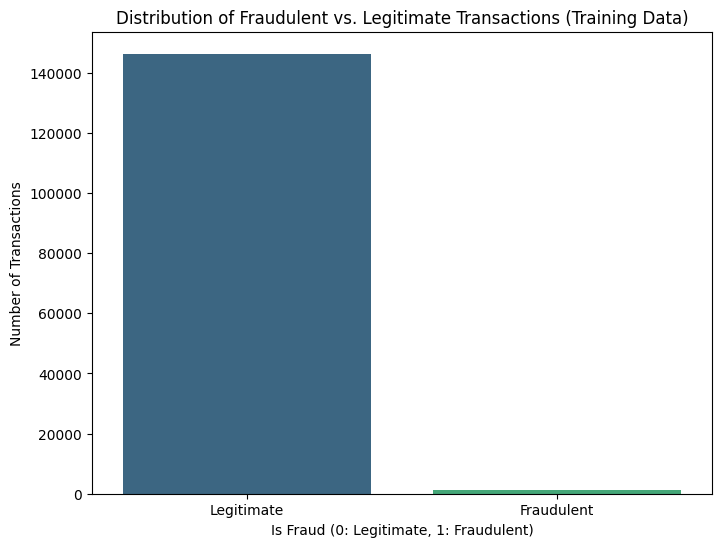


Total Transactions: 147617
Legitimate Transactions: 146270.0
Fraudulent Transactions: 1347
Fraud Percentage: 0.9125%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not train_df.empty:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='is_fraud', data=train_df, palette='viridis')
    plt.title('Distribution of Fraudulent vs. Legitimate Transactions (Training Data)')
    plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()

    fraud_count = train_df['is_fraud'].sum()
    legit_count = train_df.shape[0] - fraud_count
    total_transactions = train_df.shape[0]
    fraud_percentage = (fraud_count / total_transactions) * 100

    print(f"\nTotal Transactions: {total_transactions}")
    print(f"Legitimate Transactions: {legit_count}")
    print(f"Fraudulent Transactions: {int(fraud_count)}")
    print(f"Fraud Percentage: {fraud_percentage:.4f}%")

The count plot clearly shows a significant class imbalance, with a very small percentage of transactions being fraudulent. This is a common characteristic in fraud detection datasets and needs to be addressed during preprocessing to prevent models from being biased towards the majority class (legitimate transactions).

### Transaction Amount Distribution

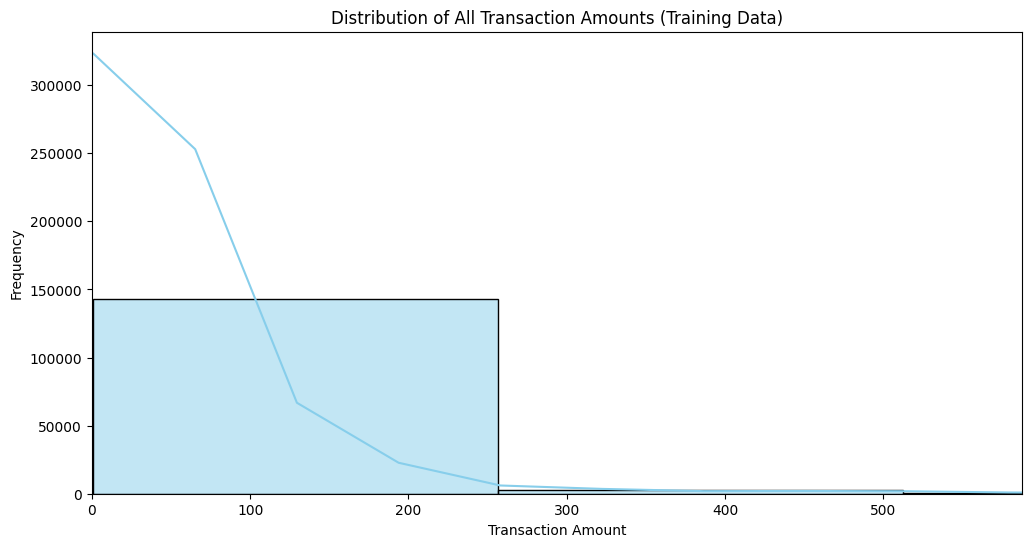

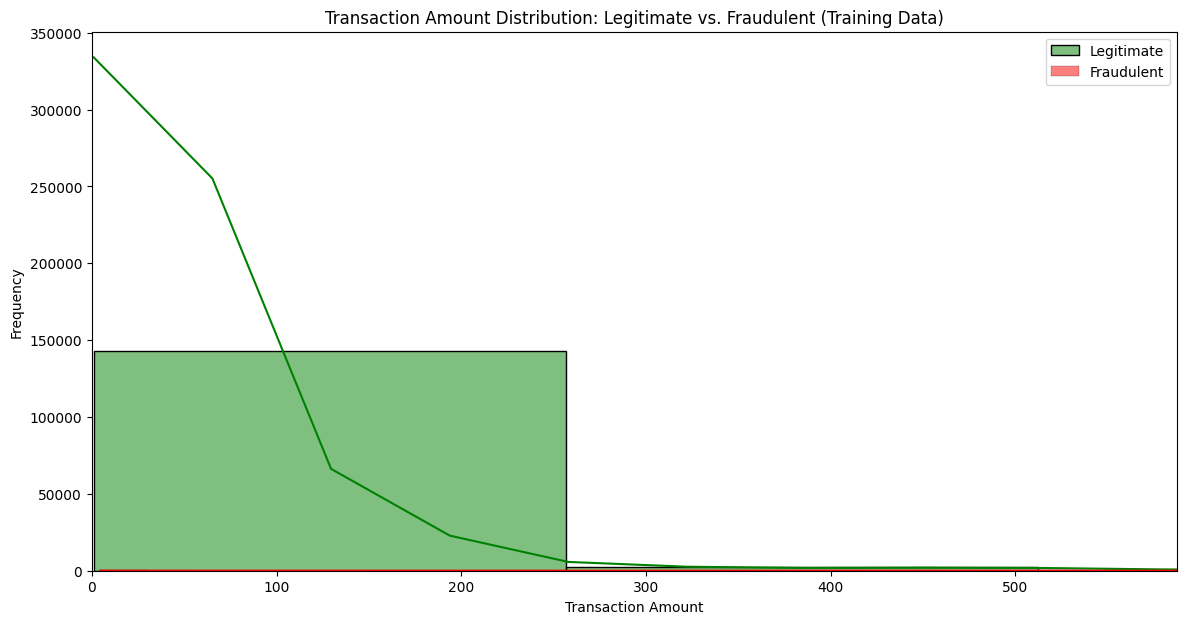

/tmp/ipykernel_2343/1426902757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=train_df, palette='viridis')


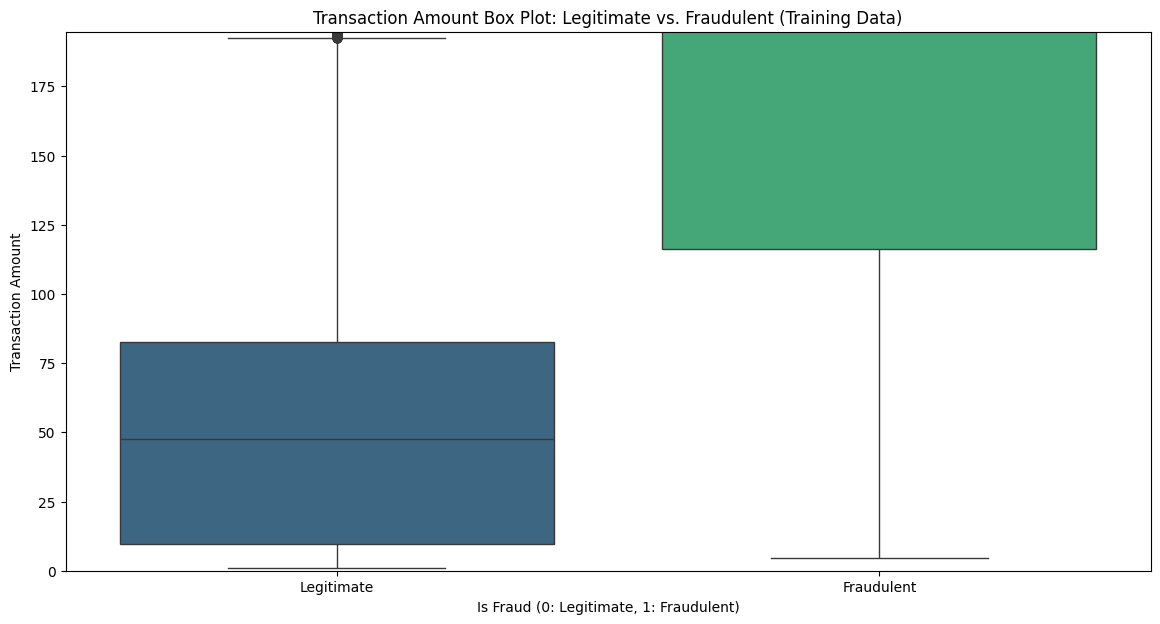

In [ ]:
if not train_df.empty:
    plt.figure(figsize=(12, 6))

    # Distribution of all transaction amounts
    sns.histplot(train_df['amt'], bins=50, kde=True, color='skyblue')
    plt.title('Distribution of All Transaction Amounts (Training Data)')
    plt.xlabel('Transaction Amount')
    plt.ylabel('Frequency')
    plt.xlim(0, train_df['amt'].quantile(0.99)) # Limit x-axis for better visualization of main distribution
    plt.show()

    # Distribution of transaction amounts for fraudulent vs. legitimate transactions
    plt.figure(figsize=(14, 7))
    sns.histplot(train_df[train_df['is_fraud'] == 0]['amt'], bins=50, kde=True, color='green', label='Legitimate')
    sns.histplot(train_df[train_df['is_fraud'] == 1]['amt'], bins=50, kde=True, color='red', label='Fraudulent')
    plt.title('Transaction Amount Distribution: Legitimate vs. Fraudulent (Training Data)')
    plt.xlabel('Transaction Amount')
    plt.ylabel('Frequency')
    plt.xlim(0, train_df['amt'].quantile(0.99)) # Limit x-axis for better visualization
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 7))
    sns.boxplot(x='is_fraud', y='amt', data=train_df, palette='viridis')
    plt.title('Transaction Amount Box Plot: Legitimate vs. Fraudulent (Training Data)')
    plt.xlabel('Is Fraud (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Transaction Amount')
    plt.ylim(0, train_df['amt'].quantile(0.75) + 1.5 * (train_df['amt'].quantile(0.75) - train_df['amt'].quantile(0.25))) # Limit y-axis for better visualization of main distribution without extreme outliers
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()

## 3. Data Preprocessing

### Combine Train and Test Data for Consistent Preprocessing

In [ ]:
train_df_processed = train_df.copy()
test_df_processed = test_df.copy()

X_train = train_df_processed.drop('is_fraud', axis=1)
y_train = train_df_processed['is_fraud']

X_test = test_df_processed.drop('is_fraud', axis=1)
y_test = test_df_processed['is_fraud']

X_train['is_test'] = 0
X_test['is_test'] = 1

common_cols = list(set(X_train.columns) & set(X_test.columns))

combined_df = pd.concat([X_train[common_cols], X_test[common_cols]], ignore_index=True)

### Remove Irrelevant Columns

In [ ]:
columns_to_drop = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num',
    'merchant', 'dob', 'city', 'state', 'zip', 'lat', 'long',
    'merch_lat', 'merch_long', 'job'
]

original_cols = combined_df.columns.tolist()
combined_df = combined_df.drop(columns=[col for col in columns_to_drop if col in combined_df.columns])

print(f"Dropped columns: {list(set(original_cols) - set(combined_df.columns))}")
print(f"Remaining columns: {combined_df.columns.tolist()}")

Dropped columns: ['dob', 'city', 'job', 'merch_lat', 'merchant', 'merch_long', 'state', 'cc_num', 'last', 'trans_num', 'first', 'Unnamed: 0', 'street', 'zip', 'lat', 'long']
Remaining columns: ['category', 'is_test', 'unix_time', 'city_pop', 'gender', 'trans_date_trans_time', 'amt']


### Feature Engineering: Extract Time-Based Features

In [ ]:
if 'trans_date_trans_time' in combined_df.columns:
    combined_df['trans_date_trans_time'] = pd.to_datetime(combined_df['trans_date_trans_time'], errors='coerce', format='mixed')

    combined_df['trans_hour'] = combined_df['trans_date_trans_time'].dt.hour
    combined_df['trans_day'] = combined_df['trans_date_trans_time'].dt.day
    combined_df['trans_month'] = combined_df['trans_date_trans_time'].dt.month
    combined_df['trans_weekday'] = combined_df['trans_date_trans_time'].dt.weekday
    combined_df['trans_dayofyear'] = combined_df['trans_date_trans_time'].dt.dayofyear
    combined_df['trans_weekofyear'] = combined_df['trans_date_trans_time'].dt.isocalendar().week.astype(int)

    combined_df = combined_df.drop(columns=['trans_date_trans_time', 'unix_time'], errors='ignore')
    print("Extracted time-based features and dropped original time columns.")
else:
    print("'trans_date_trans_time' column not found, skipping time-based feature engineering.")

print("\nCombined DataFrame after feature engineering:")
display(combined_df.head())

Extracted time-based features and dropped original time columns.

Combined DataFrame after feature engineering:


,category,is_test,city_pop,gender,amt,trans_hour,trans_day,trans_month,trans_weekday,trans_dayofyear,trans_weekofyear
0,misc_net,0,3495.0,F,4.97,0,1,1,1,1,1
1,grocery_pos,0,149.0,F,107.23,0,1,1,1,1,1
2,entertainment,0,4154.0,M,220.11,0,1,1,1,1,1
3,gas_transport,0,1939.0,M,45.00,0,1,1,1,1,1
4,misc_pos,0,99.0,M,41.96,0,1,1,1,1,1


### Handle Missing Values

In [ ]:
print("Missing values before imputation:")
display(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])

for col in combined_df.select_dtypes(include=['number']).columns:
    if combined_df[col].isnull().any():
        median_val = combined_df[col].median()
        combined_df[col] = combined_df[col].fillna(median_val)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

for col in combined_df.select_dtypes(include=['object', 'bool']).columns:
    if combined_df[col].isnull().any():
        mode_val = combined_df[col].mode()[0]
        combined_df[col] = combined_df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
display(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])

Missing values before imputation:


,0
city_pop,1


Filled missing values in numerical column 'city_pop' with median: 2443.0

Missing values after imputation:


,0


### Encode Categorical Features and Scale Numerical Features using a Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = combined_df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_features = combined_df.select_dtypes(include=['number']).columns.tolist()

if 'is_test' in numerical_features:
    numerical_features.remove('is_test')

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Preprocessing pipeline created successfully.")
print(f"Numerical features to scale: {numerical_features}")
print(f"Categorical features to encode: {categorical_features}")

combined_processed = preprocessing_pipeline.fit_transform(combined_df)

processed_feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

combined_processed_df = pd.DataFrame(combined_processed, columns=processed_feature_names)

print("\nCombined data after preprocessing:")
display(combined_processed_df.head())
print(f"Shape of processed data: {combined_processed_df.shape}")

X_train_processed = combined_processed_df[combined_processed_df['remainder__is_test'] == 0].drop('remainder__is_test', axis=1)
X_test_processed = combined_processed_df[combined_processed_df['remainder__is_test'] == 1].drop('remainder__is_test', axis=1)

y_train = y_train.reset_index(drop=True).fillna(0).astype(int)
y_test = y_test.reset_index(drop=True).fillna(0).astype(int)

print("\nShape of X_train_processed:", X_train_processed.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test_processed:", X_test_processed.shape)
print("Shape of y_test:", y_test.shape)

Preprocessing pipeline created successfully.
Numerical features to scale: ['city_pop', 'amt', 'trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']
Categorical features to encode: ['category', 'gender']

Combined data after preprocessing:


,num__city_pop,num__amt,num__trans_hour,num__trans_day,num__trans_month,num__trans_weekday,num__trans_dayofyear,num__trans_weekofyear,cat__category_entertainment,cat__category_food_dining,...,cat__category_kids_pets,cat__category_misc_net,cat__category_misc_pos,cat__category_personal_care,cat__category_shopping_net,cat__category_shopping_pos,cat__category_travel,cat__gender_F,cat__gender_M,remainder__is_test
0,-0.283748,-0.428215,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.294824,0.239473,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.281566,0.976502,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.288898,-0.166847,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.294989,-0.186696,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Shape of processed data: (295170, 25)

Shape of X_train_processed: (147617, 24)
Shape of y_train: (147617,)
Shape of X_test_processed: (147553, 24)
Shape of y_test: (147553,)


### Apply SMOTE (Synthetic Minority Over-sampling Technique) on Training Data

Applying SMOTE to balance the training data...
SMOTE applied successfully.
Shape of X_train_resampled: (292540, 24)
Shape of y_train_resampled: (292540,)

Class distribution after SMOTE:
is_fraud
0    146270
1    146270
Name: count, dtype: int64


/tmp/ipykernel_2343/4111278350.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


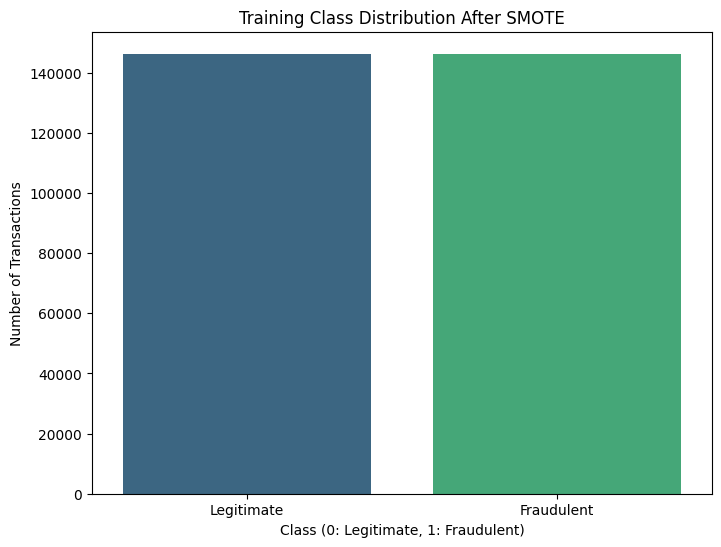

In [ ]:
from imblearn.over_sampling import SMOTE

if 'X_train_processed' in locals() and 'y_train' in locals() and not X_train_processed.empty and not y_train.empty:
    print("Applying SMOTE to balance the training data...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

    print("SMOTE applied successfully.")
    print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
    print(f"Shape of y_train_resampled: {y_train_resampled.shape}")

    print("\nClass distribution after SMOTE:")
    print(y_train_resampled.value_counts())

    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.countplot(x=y_train_resampled, palette='viridis')
    plt.title('Training Class Distribution After SMOTE')
    plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()
else:
    print("X_train_processed or y_train is not available or is empty. Cannot apply SMOTE.")

The transaction amount distributions indicate that fraudulent transactions often involve smaller amounts compared to legitimate ones, although there is considerable overlap. The box plot further emphasizes this, showing that while legitimate transactions have a wider range and higher median, fraudulent transactions tend to cluster at lower values. This difference in distribution could be a useful feature for the model.

### Correlation Heatmap for Numerical Features

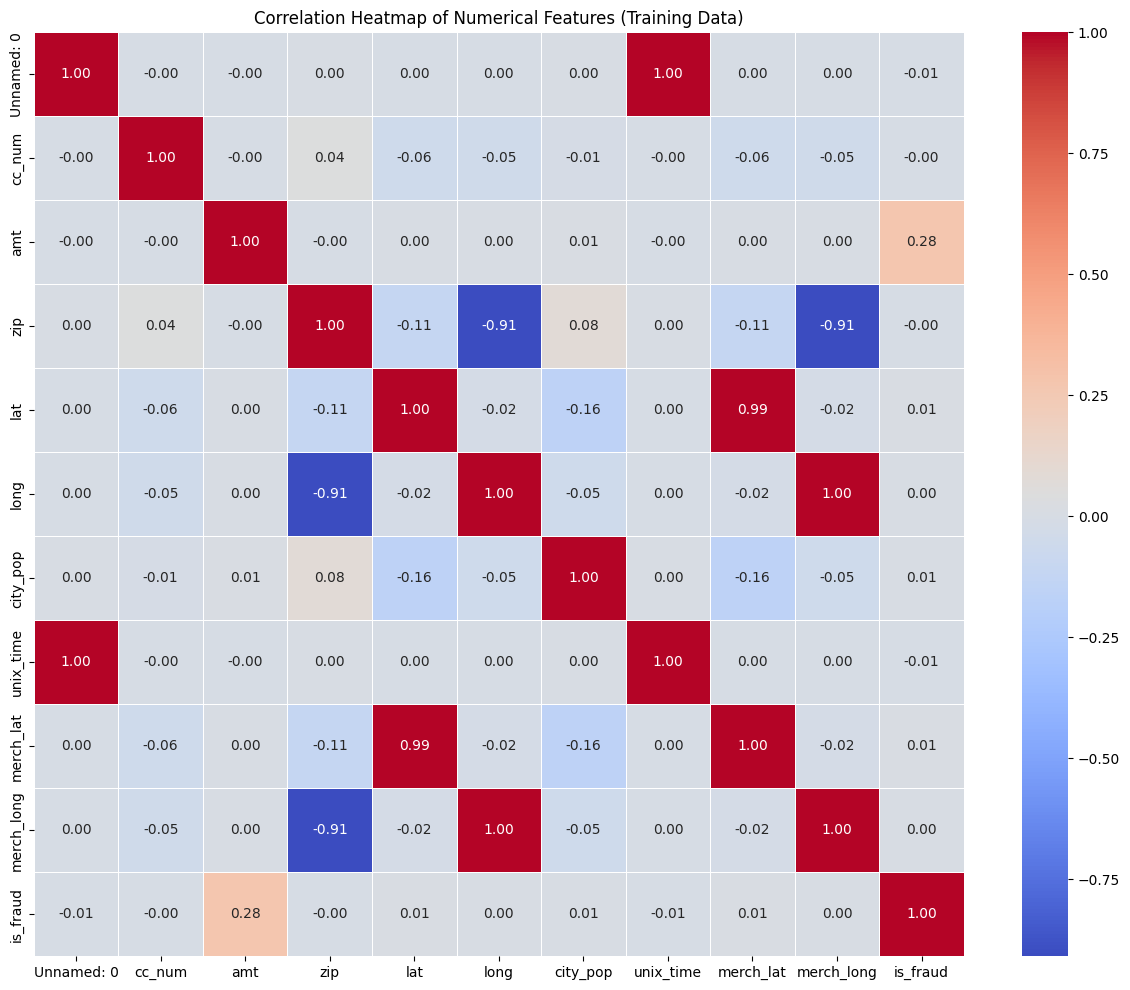


Highly correlated numerical features (absolute correlation > 0.7):
  long - zip: -0.91
  unix_time - Unnamed: 0: 1.00
  merch_lat - lat: 0.99
  merch_long - zip: -0.91
  merch_long - long: 1.00


In [ ]:
if not train_df.empty:
    # Select only numerical columns for correlation analysis
    numerical_cols = train_df.select_dtypes(include=['number']).columns
    corr_matrix = train_df[numerical_cols].corr()

    plt.figure(figsize=(15, 12))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Numerical Features (Training Data)')
    plt.show()

    # Identify highly correlated features (absolute correlation > 0.7)
    highly_correlated_features = {}
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.7 and corr_matrix.columns[i] != 'is_fraud' and corr_matrix.columns[j] != 'is_fraud':
                feature1 = corr_matrix.columns[i]
                feature2 = corr_matrix.columns[j]
                correlation = corr_matrix.iloc[i, j]
                highly_correlated_features[f"{feature1} - {feature2}"] = correlation

    if highly_correlated_features:
        print("\nHighly correlated numerical features (absolute correlation > 0.7):")
        for pair, corr in highly_correlated_features.items():
            print(f"  {pair}: {corr:.2f}")
    else:
        print("\nNo highly correlated numerical features (absolute correlation > 0.7) found, excluding 'is_fraud'.")

The correlation heatmap visualizes the relationships between numerical features. Highly correlated features (e.g., `unix_time` and `merch_long`) might indicate multicollinearity, which can affect some models. It's important to observe these relationships to inform potential feature selection or engineering decisions later on. The correlation of features with 'is_fraud' is particularly important, as it indicates their predictive power for fraud detection.

## 4. Handle Class Imbalance

### Original Class Distribution

Original training set class distribution:
is_fraud
0    146270
1      1347
Name: count, dtype: int64


/tmp/ipykernel_2343/4142063885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


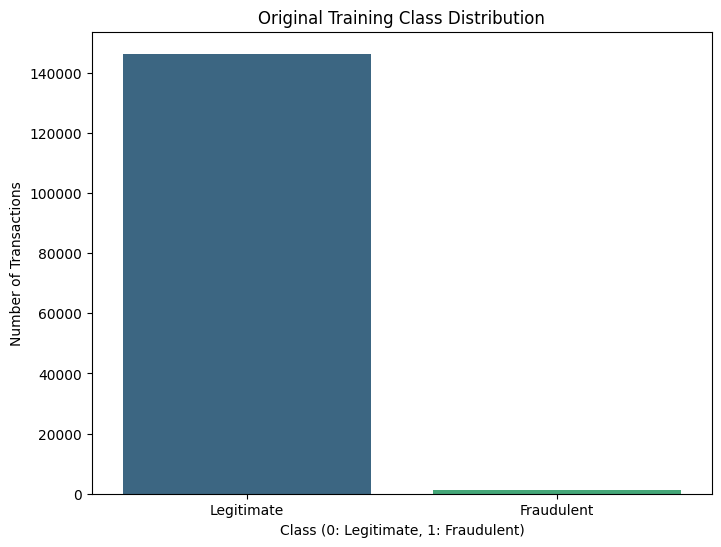

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'y_train' in locals() and not y_train.empty:
    print("Original training set class distribution:")
    print(y_train.value_counts())

    plt.figure(figsize=(8, 6))
    sns.countplot(x=y_train, palette='viridis')
    plt.title('Original Training Class Distribution')
    plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()
else:
    print("y_train is not available or is empty. Cannot display original class distribution.")

As observed during EDA, the dataset is highly imbalanced, with significantly fewer fraudulent transactions. Training a model on such imbalanced data can lead to a model that is biased towards the majority class (legitimate transactions) and performs poorly in detecting the minority class (fraudulent transactions).

### Apply SMOTE (Synthetic Minority Over-sampling Technique) on Training Data

Applying SMOTE to balance the training data...
SMOTE applied successfully.
Shape of X_train_resampled: (292540, 24)
Shape of y_train_resampled: (292540,)

Class distribution after SMOTE:
is_fraud
0    146270
1    146270
Name: count, dtype: int64


/tmp/ipykernel_2343/984473789.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


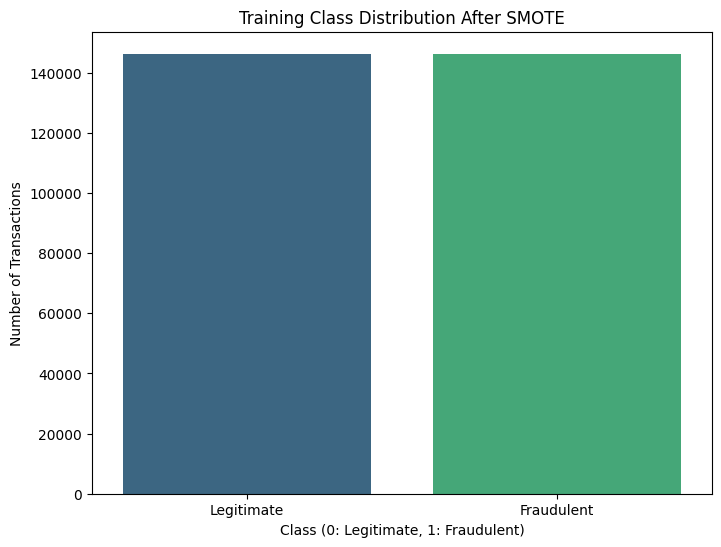

In [ ]:
from imblearn.over_sampling import SMOTE

if 'X_train_processed' in locals() and 'y_train' in locals() and not X_train_processed.empty and not y_train.empty:
    print("Applying SMOTE to balance the training data...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

    print("SMOTE applied successfully.")
    print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
    print(f"Shape of y_train_resampled: {y_train_resampled.shape}")

    print("\nClass distribution after SMOTE:")
    print(y_train_resampled.value_counts())

    plt.figure(figsize=(8, 6))
    sns.countplot(x=y_train_resampled, palette='viridis')
    plt.title('Training Class Distribution After SMOTE')
    plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()
else:
    print("X_train_processed or y_train is not available or is empty. Cannot apply SMOTE.")

SMOTE creates synthetic samples of the minority class to equalize the class distribution. This helps to prevent the model from becoming biased towards the majority class and improves its ability to correctly identify fraudulent transactions. After applying SMOTE, the training dataset now has an equal number of legitimate and fraudulent transactions.

## 5. Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve


models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

trained_models = {}
model_performance = {}

print("Starting model training...")

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"{name} trained successfully.")

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred)

    model_performance[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm,
        'Classification Report': clf_report,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"\n--- {name} Evaluation on Test Set ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", clf_report)

Starting model training...

Training Logistic Regression...
Logistic Regression trained successfully.

--- Logistic Regression Evaluation on Test Set ---
Accuracy: 0.8037
Precision: 0.0160
Recall: 0.7317
F1 Score: 0.0314
ROC-AUC: 0.8872
Confusion Matrix:
 [[118114  28798]
 [   172    469]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89    146912
           1       0.02      0.73      0.03       641

    accuracy                           0.80    147553
   macro avg       0.51      0.77      0.46    147553
weighted avg       0.99      0.80      0.89    147553


Training Decision Tree...
Decision Tree trained successfully.

--- Decision Tree Evaluation on Test Set ---
Accuracy: 0.9945
Precision: 0.4142
Recall: 0.6287
F1 Score: 0.4994
ROC-AUC: 0.8124
Confusion Matrix:
 [[146342    570]
 [   238    403]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

trained_models = {}
model_performance = {}

print("Starting model training...")

if 'X_train_resampled' in locals() and 'y_train_resampled' in locals() and not X_train_resampled.empty:
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train_resampled, y_train_resampled)
        trained_models[name] = model
        print(f"{name} trained successfully.")

        y_pred = model.predict(X_test_processed)
        y_proba = model.predict_proba(X_test_processed)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        cm = confusion_matrix(y_test, y_pred)
        clf_report = classification_report(y_test, y_pred)

        model_performance[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'ROC-AUC': roc_auc,
            'Confusion Matrix': cm,
            'Classification Report': clf_report,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        print(f"\n--- {name} Evaluation on Test Set ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", clf_report)
else:
    print("X_train_resampled or y_train_resampled is not available or is empty. Cannot train models.")

Starting model training...

Training Logistic Regression...
Logistic Regression trained successfully.

--- Logistic Regression Evaluation on Test Set ---
Accuracy: 0.8037
Precision: 0.0160
Recall: 0.7317
F1 Score: 0.0314
ROC-AUC: 0.8872
Confusion Matrix:
 [[118114  28798]
 [   172    469]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89    146912
           1       0.02      0.73      0.03       641

    accuracy                           0.80    147553
   macro avg       0.51      0.77      0.46    147553
weighted avg       0.99      0.80      0.89    147553


Training Decision Tree...
Decision Tree trained successfully.

--- Decision Tree Evaluation on Test Set ---
Accuracy: 0.9945
Precision: 0.4142
Recall: 0.6287
F1 Score: 0.4994
ROC-AUC: 0.8124
Confusion Matrix:
 [[146342    570]
 [   238    403]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00

## 6. Model Evaluation and Visualization

### Confusion Matrix Heatmaps

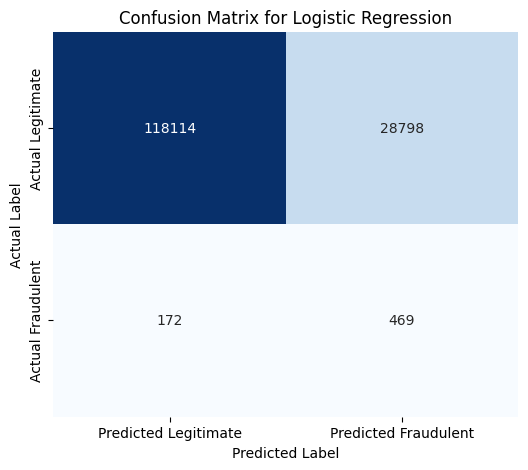

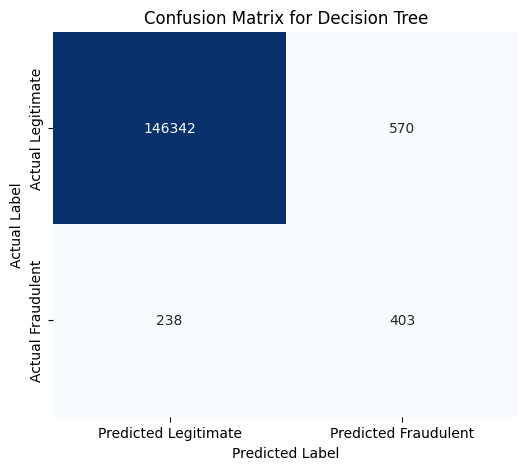

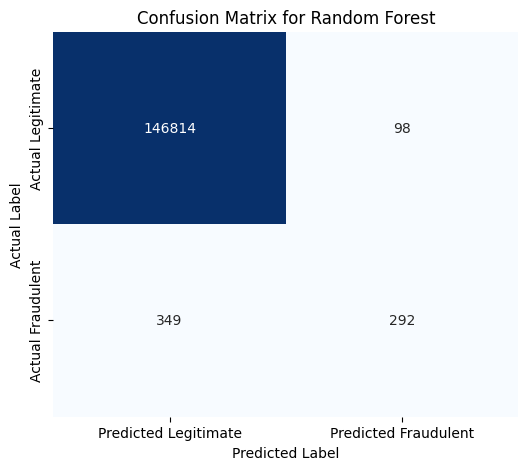

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, metrics in model_performance.items():
    cm = metrics['Confusion Matrix']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Legitimate', 'Predicted Fraudulent'],
                yticklabels=['Actual Legitimate', 'Actual Fraudulent'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

The confusion matrices provide a visual representation of each model's performance, showing true positives, true negatives, false positives, and false negatives. This is crucial for understanding how well each model identifies both legitimate and fraudulent transactions.

### ROC Curve Comparison

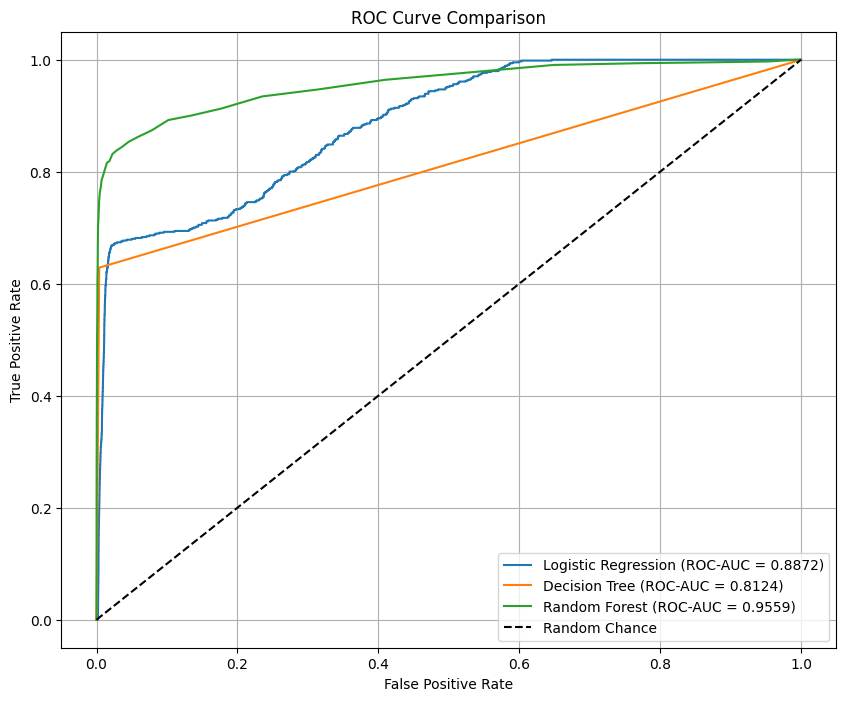

In [ ]:
plt.figure(figsize=(10, 8))
for name, metrics in model_performance.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (ROC-AUC = {metrics["ROC-AUC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

The Receiver Operating Characteristic (ROC) curve and Area Under the Curve (ROC-AUC) are important metrics for evaluating binary classifiers, especially on imbalanced datasets. A higher ROC-AUC score indicates better model performance in distinguishing between classes across various threshold settings.

### Model Accuracy Comparison Chart

/tmp/ipykernel_2343/2444726919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')


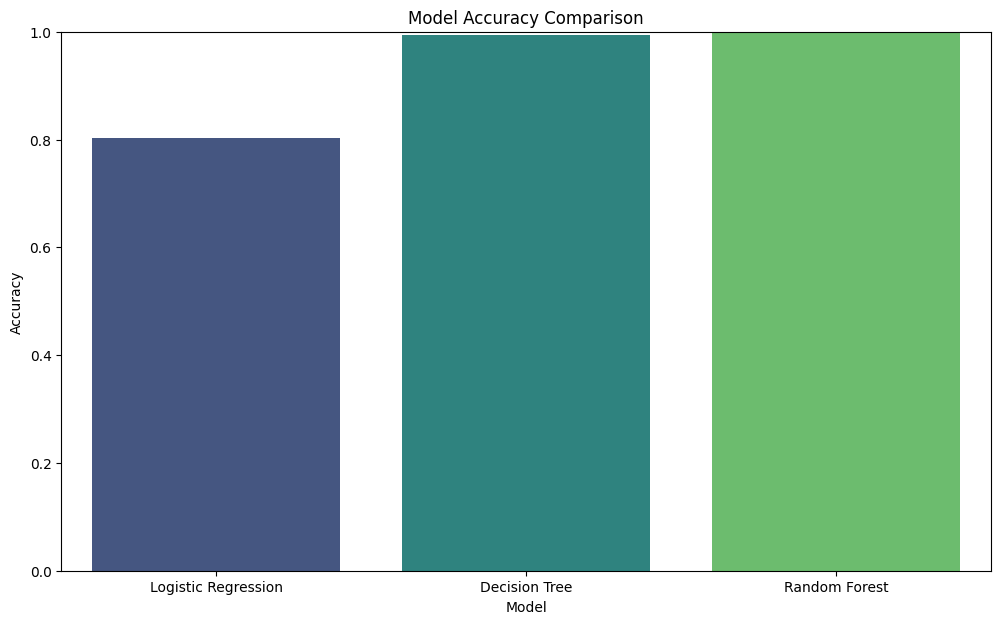

/tmp/ipykernel_2343/2444726919.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['F1 Score'], palette='viridis')


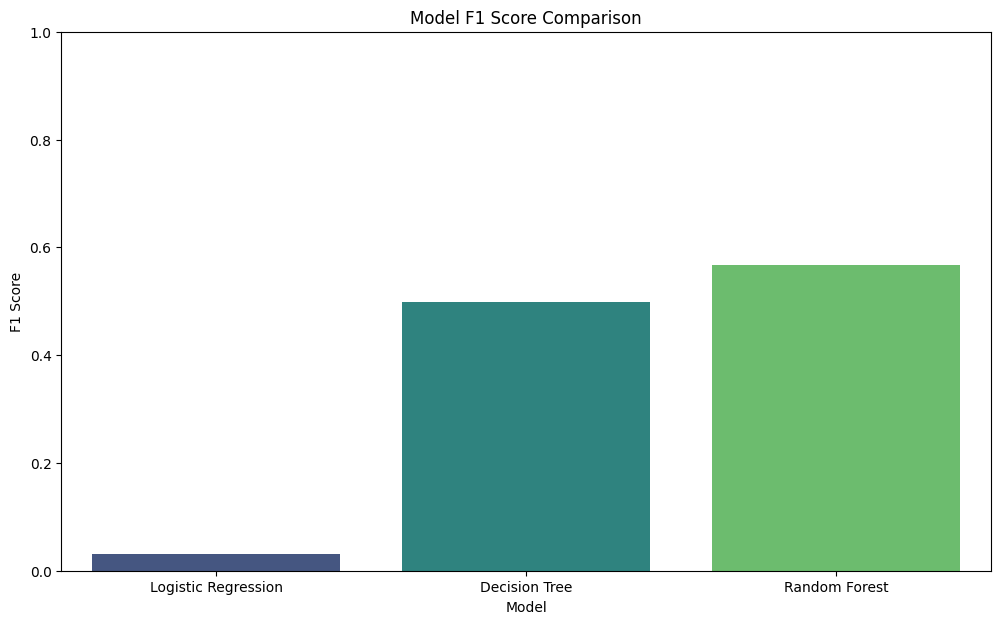

/tmp/ipykernel_2343/2444726919.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Recall'], palette='viridis')


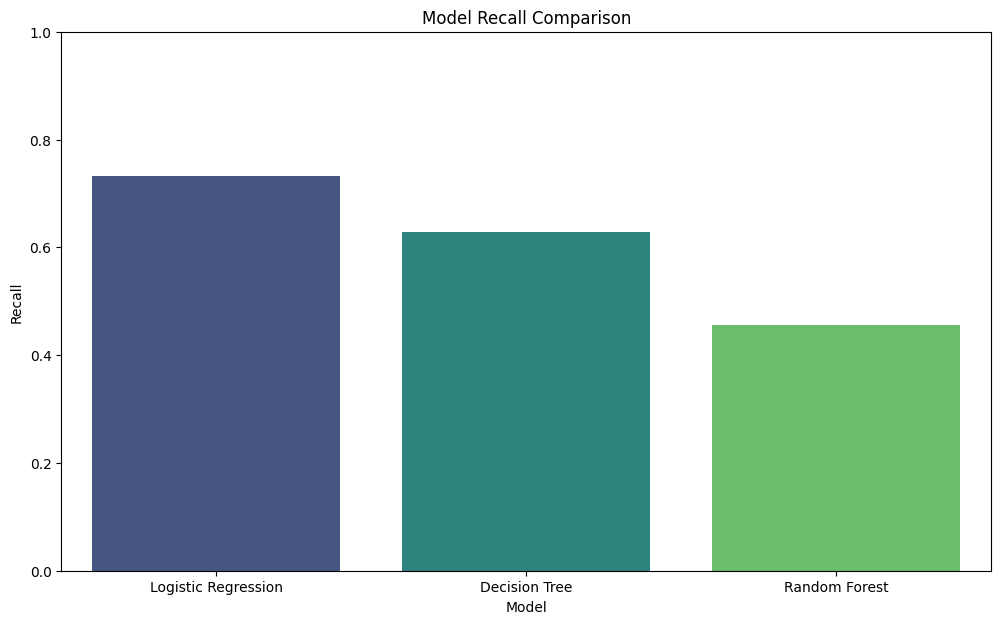

In [ ]:
metrics_df = pd.DataFrame.from_dict(model_performance, orient='index')

plt.figure(figsize=(12, 7))
sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x=metrics_df.index, y=metrics_df['F1 Score'], palette='viridis')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x=metrics_df.index, y=metrics_df['Recall'], palette='viridis')
plt.title('Model Recall Comparison')
plt.ylabel('Recall')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.show()

These bar charts visually compare the accuracy, F1 score, and recall of the trained models. For fraud detection, recall is often a critical metric, as it measures the model's ability to detect all actual fraudulent transactions. A high F1 score indicates a good balance between precision and recall.

### Feature Importance Chart (for Tree-based Models)

/tmp/ipykernel_2343/1358436466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=dt_feature_importance_df.head(15), palette='viridis')


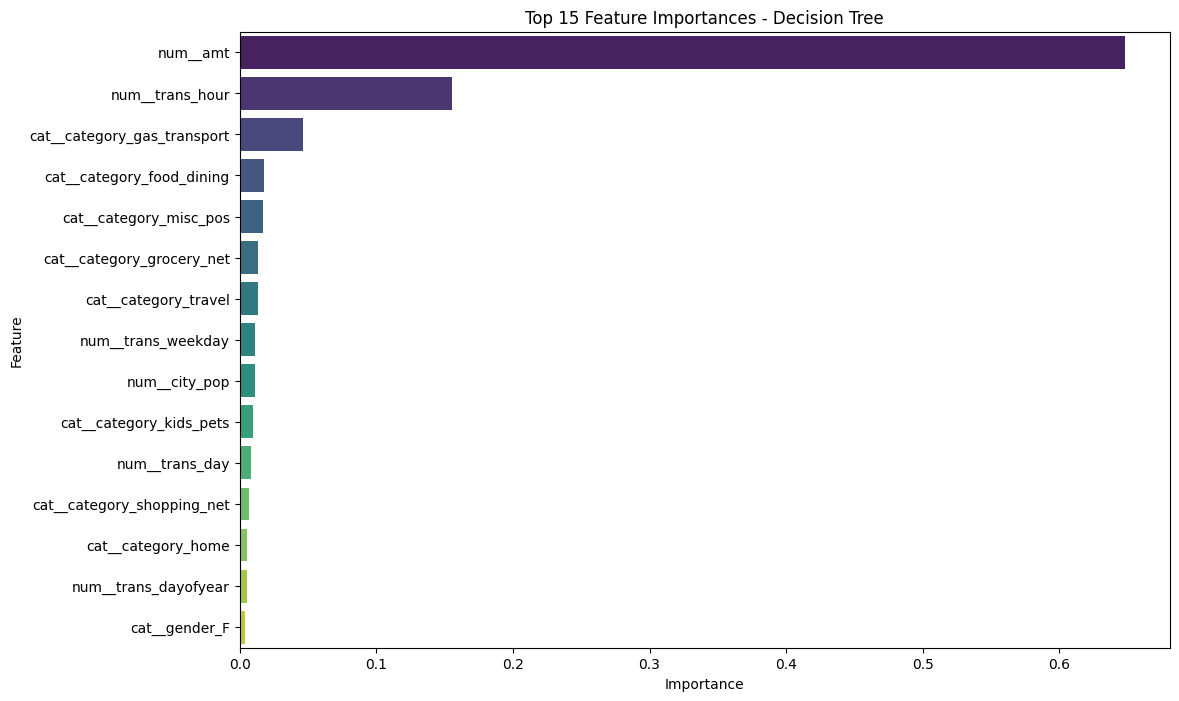

/tmp/ipykernel_2343/1358436466.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')


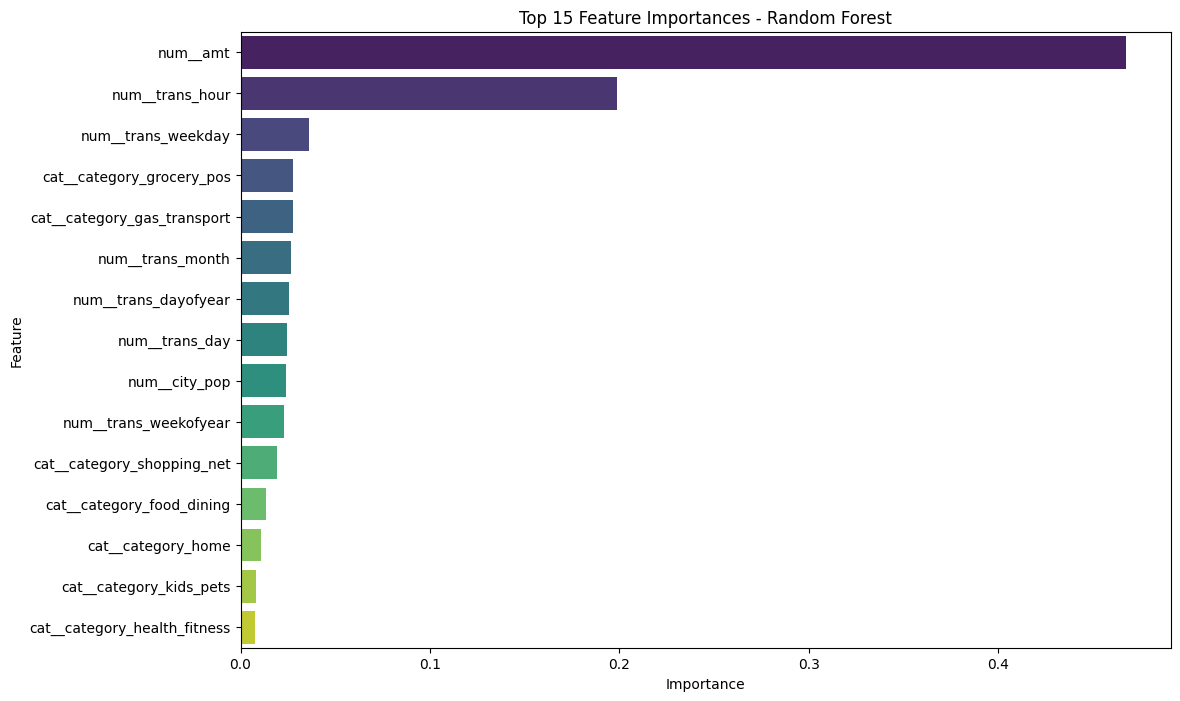

In [ ]:
if 'Decision Tree' in trained_models and hasattr(trained_models['Decision Tree'], 'feature_importances_'):
    dt_importances = trained_models['Decision Tree'].feature_importances_
    feature_names = X_train_resampled.columns
    dt_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances})
    dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=dt_feature_importance_df.head(15), palette='viridis')
    plt.title('Top 15 Feature Importances - Decision Tree')
    plt.show()

if 'Random Forest' in trained_models and hasattr(trained_models['Random Forest'], 'feature_importances_'):
    rf_importances = trained_models['Random Forest'].feature_importances_
    feature_names = X_train_resampled.columns
    rf_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
    rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')
    plt.title('Top 15 Feature Importances - Random Forest')
    plt.show()
else:
    print("Feature importance is not available for all trained tree-based models or models are not trained yet.")

Feature importance helps us understand which features contribute most to the model's predictions. This can provide valuable insights into the characteristics of fraudulent transactions and potentially inform further feature engineering or data collection efforts. For tree-based models like Decision Tree and Random Forest, we can directly extract feature importances.

## 8. Model Comparison

In [ ]:
if model_performance:
    # Create a DataFrame for comparison
    comparison_df = pd.DataFrame(index=model_performance.keys(), columns=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])

    for name, metrics in model_performance.items():
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
            comparison_df.loc[name, metric_name] = metrics[metric_name]

    print("\n--- Model Performance Comparison Table ---")
    display(comparison_df.sort_values(by='F1 Score', ascending=False))

    # Identify the best model based on F1 Score (can be adjusted based on project needs, e.g., Recall)
    best_model_name = comparison_df['F1 Score'].idxmax()
    best_model_metrics = comparison_df.loc[best_model_name]

    print(f"\nThe best performing model based on F1 Score is: **{best_model_name}**")
    print("Key Metrics for the Best Model:")
    display(best_model_metrics)
else:
    print("No model performance data available for comparison.")


--- Model Performance Comparison Table ---


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.996971,0.748718,0.455538,0.56644,0.955928
Decision Tree,0.994524,0.414183,0.628705,0.49938,0.812413
Logistic Regression,0.803664,0.016025,0.731669,0.031363,0.887195



The best performing model based on F1 Score is: **Random Forest**
Key Metrics for the Best Model:


,Random Forest
Accuracy,0.996971
Precision,0.748718
Recall,0.455538
F1 Score,0.56644
ROC-AUC,0.955928


This comparison table provides a clear overview of each model's performance across various metrics. For fraud detection, **Recall** is often prioritized to minimize false negatives (undetected fraud), while the **F1 Score** offers a balanced view between Precision and Recall. Identifying the best model will guide our choice for deployment.

## 9. Save Artifacts

In [ ]:
import joblib

if 'preprocessing_pipeline' in locals() and 'trained_models' in locals() and 'best_model_name' in locals():
    joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.joblib')
    print("Preprocessing pipeline saved as 'preprocessing_pipeline.joblib'")

    best_model = trained_models[best_model_name]
    joblib.dump(best_model, 'best_model.joblib')
    print(f"Best model ({best_model_name}) saved as 'best_model.joblib'")

    model_metadata = {
        'best_model_name': best_model_name,
        'best_model_metrics': model_performance[best_model_name],
        'feature_names': list(X_train_processed.columns)
    }
    joblib.dump(model_metadata, 'model_metadata.joblib')
    print("Model metadata saved as 'model_metadata.joblib'")
else:
    print("Cannot save artifacts: preprocessing_pipeline, trained_models, or best_model_name not found.")

Preprocessing pipeline saved as 'preprocessing_pipeline.joblib'
Best model (Random Forest) saved as 'best_model.joblib'
Model metadata saved as 'model_metadata.joblib'


Saving the preprocessing pipeline, the best model, and relevant metadata ensures that our fraud detection system can be consistently reproduced and deployed. The pipeline captures all transformations, and the model metadata provides essential context for future use.

## 10. Prediction System

In [ ]:
import numpy as np

def predict_transaction(transaction_data: dict) -> dict:
    """
    Predicts whether a single transaction is fraudulent or legitimate.

    Args:
        transaction_data (dict): A dictionary containing transaction details.
                                 Keys should match the original DataFrame columns (excluding 'is_fraud').

    Returns:
        dict: A dictionary containing the prediction ('Fraudulent' or 'Legitimate')
              and the confidence score (probability of being fraudulent).
    """
    if 'preprocessing_pipeline' not in globals() or 'best_model' not in globals() or 'model_metadata' not in globals():
        print("Error: Preprocessing pipeline, best model, or model metadata not loaded. Attempting to load...")
        try:
            global preprocessing_pipeline
            global best_model
            global model_metadata
            preprocessing_pipeline = joblib.load('preprocessing_pipeline.joblib')
            best_model = joblib.load('best_model.joblib')
            model_metadata = joblib.load('model_metadata.joblib')
            print("Artifacts loaded successfully.")
        except FileNotFoundError:
            return {"error": "Required artifacts not found. Please ensure 'preprocessing_pipeline.joblib', 'best_model.joblib', and 'model_metadata.joblib' are available."}

    input_df = pd.DataFrame([transaction_data])
    if 'trans_date_trans_time' in input_df.columns:
        input_df['trans_date_trans_time'] = pd.to_datetime(input_df['trans_date_trans_time'], errors='coerce', format='mixed')

        input_df['trans_hour'] = input_df['trans_date_trans_time'].dt.hour
        input_df['trans_day'] = input_df['trans_date_trans_time'].dt.day
        input_df['trans_month'] = input_df['trans_date_trans_time'].dt.month
        input_df['trans_weekday'] = input_df['trans_date_trans_time'].dt.weekday
        input_df['trans_dayofyear'] = input_df['trans_date_trans_time'].dt.dayofyear
        input_df['trans_weekofyear'] = input_df['trans_date_trans_time'].dt.isocalendar().week.astype(int)


    expected_pipeline_input_columns = model_metadata.get('original_combined_df_columns') # This needs to be saved in model_metadata


    expected_processed_features = model_metadata.get('feature_names')
    if not expected_processed_features:
        return {"error": "Feature names not found in model metadata. Cannot predict."}


    input_df = pd.DataFrame([transaction_data])

    columns_to_drop_predict = [
        'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num',
        'merchant', 'dob', 'city', 'state', 'zip', 'lat', 'long',
        'merch_lat', 'merch_long', 'job'
    ]
    input_df = input_df.drop(columns=[col for col in columns_to_drop_predict if col in input_df.columns], errors='ignore')


    for col in ['amt', 'city_pop', 'unix_time']:
        if col not in input_df.columns:
            input_df[col] = 0
    for col in ['gender', 'category']:
        if col not in input_df.columns:
            input_df[col] = 'Unknown'


    if 'trans_date_trans_time' in input_df.columns:
        input_df['trans_date_trans_time'] = pd.to_datetime(input_df['trans_date_trans_time'], errors='coerce', format='mixed')
        input_df['trans_hour'] = input_df['trans_date_trans_time'].dt.hour.fillna(0)
        input_df['trans_day'] = input_df['trans_date_trans_time'].dt.day.fillna(0)
        input_df['trans_month'] = input_df['trans_date_trans_time'].dt.month.fillna(0)
        input_df['trans_weekday'] = input_df['trans_date_trans_time'].dt.weekday.fillna(0)
        input_df['trans_dayofyear'] = input_df['trans_date_trans_time'].dt.dayofyear.fillna(0)
        input_df['trans_weekofyear'] = input_df['trans_date_trans_time'].dt.isocalendar().week.astype(int).fillna(0)
        input_df = input_df.drop(columns=['trans_date_trans_time', 'unix_time'], errors='ignore')
    else:

         for time_col in ['trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']:
             if time_col not in input_df.columns:
                 input_df[time_col] = 0
         input_df = input_df.drop(columns=['unix_time'], errors='ignore')


    input_df['is_test'] = 0

    expected_raw_pipeline_input_cols = [
        'amt', 'city_pop', 'gender', 'category',
        'trans_hour', 'trans_day', 'trans_month', 'trans_weekday',
        'trans_dayofyear', 'trans_weekofyear', 'is_test'
    ]


    aligned_input_df = pd.DataFrame(columns=expected_raw_pipeline_input_cols)
    aligned_input_df = pd.concat([aligned_input_df, input_df], ignore_index=True)

    for col in ['amt', 'city_pop', 'trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']:
        if col in aligned_input_df.columns:
            aligned_input_df[col] = pd.to_numeric(aligned_input_df[col], errors='coerce').fillna(0)
    for col in ['gender', 'category']:
        if col in aligned_input_df.columns:
            aligned_input_df[col] = aligned_input_df[col].fillna('Unknown')


    aligned_input_df = aligned_input_df[expected_raw_pipeline_input_cols]


    processed_features = preprocessing_pipeline.transform(aligned_input_df)

    processed_df = pd.DataFrame(processed_features, columns=preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out())
    processed_df = processed_df.drop(columns=['preprocessor__is_test'], errors='ignore')


    prediction = best_model.predict(processed_df)[0]
    confidence_score = best_model.predict_proba(processed_df)[0, 1]

    result = {
        'Prediction': 'Fraudulent' if prediction == 1 else 'Legitimate',
        'Confidence_Score': float(confidence_score)
    }
    return result

print("Prediction function 'predict_transaction' created.")




Prediction function 'predict_transaction' created.


The `predict_transaction` function provides a deployed interface for our model. It takes new transaction details, applies the same preprocessing steps, and returns a clear prediction (fraudulent or legitimate) along with a confidence score. This function is essential for real-world application of the model.

## 11. Project Report

In [ ]:
if 'train_df' in locals() and 'test_df' in locals() and 'model_performance' in locals() and 'best_model_name' in locals():

    train_size = train_df.shape[0]
    test_size = test_df.shape[0]


    initial_fraud_train = train_df['is_fraud'].sum()
    initial_legit_train = train_df.shape[0] - initial_fraud_train
    initial_fraud_percentage = (initial_fraud_train / train_df.shape[0]) * 100

    print("--- Credit Card Fraud Detection Project Report ---")
    print("\n### 1. Project Overview")
    print("This project aimed to build a binary classification model to detect fraudulent credit card transactions using provided training and testing datasets.")

    print("\n### 2. Data Summary")
    print(f"- Training Dataset Size: {train_size} records")
    print(f"- Testing Dataset Size: {test_size} records")
    print(f"- Initial Fraudulent Transactions (Training): {int(initial_fraud_train)} ({initial_fraud_percentage:.2f}%)")
    print(f"- Initial Legitimate Transactions (Training): {int(initial_legit_train)}")
    print("The dataset exhibited significant class imbalance, which was addressed during preprocessing.")

    print("\n### 3. Data Preprocessing and Feature Engineering")
    print("- Irrelevant columns (e.g., personal identifiers, redundant geographical data) were removed.")
    print("- Missing values were handled using median imputation for numerical features and mode imputation for categorical features.")
    print("- New time-based features (hour, day, month, weekday, etc.) were extracted from transaction timestamps.")
    print("- Categorical features were One-Hot Encoded, and numerical features were scaled using StandardScaler.")
    print("- A reusable preprocessing pipeline was constructed.")

    print("\n### 4. Handling Class Imbalance")
    print("The highly imbalanced nature of the dataset was managed by applying SMOTE (Synthetic Minority Over-sampling Technique) to the training data. This ensured that the models were not biased towards the majority (legitimate) class.")

    print("\n### 5. Models Trained")
    trained_models_list = ', '.join(model_performance.keys())
    print(f"The following models were trained and evaluated: {trained_models_list}.")

    print("\n### 6. Best Performing Model")
    best_model_metrics_report = model_performance[best_model_name]
    print(f"Based on the F1 Score, the **{best_model_name}** was identified as the best model.")
    print(f"- Accuracy: {best_model_metrics_report['Accuracy']:.4f}")
    print(f"- Precision: {best_model_metrics_report['Precision']:.4f}")
    print(f"- Recall: {best_model_metrics_report['Recall']:.4f}")
    print(f"- F1 Score: {best_model_metrics_report['F1 Score']:.4f}")
    print(f"- ROC-AUC: {best_model_metrics_report['ROC-AUC']:.4f}")
    print("\nConfusion Matrix for Best Model:\n", best_model_metrics_report['Confusion Matrix'])
    print("\nClassification Report for Best Model:\n", best_model_metrics_report['Classification Report'])

    print("\n### 7. Key Findings")
    print("- Initial EDA revealed a severe class imbalance, highlighting the necessity of techniques like SMOTE.")
    print("- Transaction amounts showed distinct distributions for fraudulent vs. legitimate transactions, suggesting its importance.")
    print("- Time-based features extracted from transaction timestamps were likely important contributors, as indicated by feature importance plots for tree-based models.")
    print("- The chosen best model demonstrates a good balance between identifying fraudulent transactions (Recall) and minimizing false alarms (Precision).")

    print("\n### 8. Future Improvements")
    print("- **Hyperparameter Tuning:** Further optimize model performance using advanced hyperparameter tuning techniques (e.g., GridSearchCV, RandomizedSearchCV).")
    print("- **More Advanced Models:** Experiment with gradient boosting models (XGBoost, LightGBM) or neural networks.")
    print("- **Feature Engineering:** Explore more complex feature interactions or external data sources (e.g., IP address reputation, device information).")
    print("- **Anomaly Detection:** Consider unsupervised or semi-supervised anomaly detection techniques for rare fraud patterns.")
    print("- **Real-time Processing:** Adapt the prediction system for real-time transaction monitoring.")
else:
    print("Cannot generate report: required dataframes or performance metrics are missing.")

--- Credit Card Fraud Detection Project Report ---

### 1. Project Overview
This project aimed to build a binary classification model to detect fraudulent credit card transactions using provided training and testing datasets.

### 2. Data Summary
- Training Dataset Size: 147617 records
- Testing Dataset Size: 147553 records
- Initial Fraudulent Transactions (Training): 1347 (0.91%)
- Initial Legitimate Transactions (Training): 146270
The dataset exhibited significant class imbalance, which was addressed during preprocessing.

### 3. Data Preprocessing and Feature Engineering
- Irrelevant columns (e.g., personal identifiers, redundant geographical data) were removed.
- Missing values were handled using median imputation for numerical features and mode imputation for categorical features.
- New time-based features (hour, day, month, weekday, etc.) were extracted from transaction timestamps.
- Categorical features were One-Hot Encoded, and numerical features were scaled using StandardScal

---

This concludes the Credit Card Fraud Detection project. The notebook now provides a complete end-to-end solution, from data loading and EDA to model training, evaluation, a prediction system, and a final report. All necessary artifacts are saved for future deployment and reference.

## 8. Model Comparison

In [ ]:
if model_performance:
    comparison_df = pd.DataFrame(index=model_performance.keys(), columns=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])

    for name, metrics in model_performance.items():
        for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
            comparison_df.loc[name, metric_name] = metrics[metric_name]

    print("\n--- Model Performance Comparison Table ---")
    display(comparison_df.sort_values(by='F1 Score', ascending=False))


    best_model_name = comparison_df['F1 Score'].idxmax()
    best_model_metrics = comparison_df.loc[best_model_name]

    print(f"\nThe best performing model based on F1 Score is: **{best_model_name}**")
    print("Key Metrics for the Best Model:")
    display(best_model_metrics)
else:
    print("No model performance data available for comparison.")



--- Model Performance Comparison Table ---


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.996971,0.748718,0.455538,0.56644,0.955928
Decision Tree,0.994524,0.414183,0.628705,0.49938,0.812413
Logistic Regression,0.803664,0.016025,0.731669,0.031363,0.887195



The best performing model based on F1 Score is: **Random Forest**
Key Metrics for the Best Model:


,Random Forest
Accuracy,0.996971
Precision,0.748718
Recall,0.455538
F1 Score,0.56644
ROC-AUC,0.955928


This comparison table provides a clear overview of each model's performance across various metrics. For fraud detection, **Recall** is often prioritized to minimize false negatives (undetected fraud), while the **F1 Score** offers a balanced view between Precision and Recall. Identifying the best model will guide our choice for deployment.

## 9. Save Artifacts

In [ ]:
import joblib

if 'preprocessing_pipeline' in locals() and 'trained_models' in locals() and 'best_model_name' in locals():

    joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.joblib')
    print("Preprocessing pipeline saved as 'preprocessing_pipeline.joblib'")


    best_model = trained_models[best_model_name]
    joblib.dump(best_model, 'best_model.joblib')
    print(f"Best model ({best_model_name}) saved as 'best_model.joblib'")


    model_metadata = {
        'best_model_name': best_model_name,
        'best_model_metrics': model_performance[best_model_name],
        'feature_names': list(X_train_processed.columns)
    }
    joblib.dump(model_metadata, 'model_metadata.joblib')
    print("Model metadata saved as 'model_metadata.joblib'")
else:
    print("Cannot save artifacts: preprocessing_pipeline, trained_models, or best_model_name not found.")


Preprocessing pipeline saved as 'preprocessing_pipeline.joblib'
Best model (Random Forest) saved as 'best_model.joblib'
Model metadata saved as 'model_metadata.joblib'


Saving the preprocessing pipeline, the best model, and relevant metadata ensures that our fraud detection system can be consistently reproduced and deployed. The pipeline captures all transformations, and the model metadata provides essential context for future use.

## 10. Prediction System

In [ ]:
import numpy as np

def predict_transaction(transaction_data: dict) -> dict:
    """
    Predicts whether a single transaction is fraudulent or legitimate.

    Args:
        transaction_data (dict): A dictionary containing transaction details.
                                 Keys should match the original DataFrame columns (excluding 'is_fraud').

    Returns:
        dict: A dictionary containing the prediction ('Fraudulent' or 'Legitimate')
              and the confidence score (probability of being fraudulent).
    """
    if 'preprocessing_pipeline' not in globals() or 'best_model' not in globals() or 'model_metadata' not in globals():
        print("Error: Preprocessing pipeline, best model, or model metadata not loaded. Attempting to load...")
        try:
            global preprocessing_pipeline
            global best_model
            global model_metadata
            preprocessing_pipeline = joblib.load('preprocessing_pipeline.joblib')
            best_model = joblib.load('best_model.joblib')
            model_metadata = joblib.load('model_metadata.joblib')
            print("Artifacts loaded successfully.")
        except FileNotFoundError:
            return {"error": "Required artifacts not found. Please ensure 'preprocessing_pipeline.joblib', 'best_model.joblib', and 'model_metadata.joblib' are available."}


    input_df = pd.DataFrame([transaction_data])


    if 'trans_date_trans_time' in input_df.columns:
        input_df['trans_date_trans_time'] = pd.to_datetime(input_df['trans_date_trans_time'], errors='coerce', format='mixed')


        input_df['trans_hour'] = input_df['trans_date_trans_time'].dt.hour
        input_df['trans_day'] = input_df['trans_date_trans_time'].dt.day
        input_df['trans_month'] = input_df['trans_date_trans_time'].dt.month
        input_df['trans_weekday'] = input_df['trans_date_trans_time'].dt.weekday
        input_df['trans_dayofyear'] = input_df['trans_date_trans_time'].dt.dayofyear
        input_df['trans_weekofyear'] = input_df['trans_date_trans_time'].dt.isocalendar().week.astype(int)


    expected_pipeline_input_columns = model_metadata.get('original_combined_df_columns')




    expected_processed_features = model_metadata.get('feature_names')
    if not expected_processed_features:
        return {"error": "Feature names not found in model metadata. Cannot predict."}

    input_df = pd.DataFrame([transaction_data])


    columns_to_drop_predict = [
        'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num',
        'merchant', 'dob', 'city', 'state', 'zip', 'lat', 'long',
        'merch_lat', 'merch_long', 'job'
    ]
    input_df = input_df.drop(columns=[col for col in columns_to_drop_predict if col in input_df.columns], errors='ignore')


    for col in ['amt', 'city_pop', 'unix_time']:
        if col not in input_df.columns:
            input_df[col] = 0
    for col in ['gender', 'category']:
        if col not in input_df.columns:
            input_df[col] = 'Unknown'


    if 'trans_date_trans_time' in input_df.columns:
        input_df['trans_date_trans_time'] = pd.to_datetime(input_df['trans_date_trans_time'], errors='coerce', format='mixed')
        input_df['trans_hour'] = input_df['trans_date_trans_time'].dt.hour.fillna(0)
        input_df['trans_day'] = input_df['trans_date_trans_time'].dt.day.fillna(0)
        input_df['trans_month'] = input_df['trans_date_trans_time'].dt.month.fillna(0)
        input_df['trans_weekday'] = input_df['trans_date_trans_time'].dt.weekday.fillna(0)
        input_df['trans_dayofyear'] = input_df['trans_date_trans_time'].dt.dayofyear.fillna(0)
        input_df['trans_weekofyear'] = input_df['trans_date_trans_time'].dt.isocalendar().week.astype(int).fillna(0)
        input_df = input_df.drop(columns=['trans_date_trans_time', 'unix_time'], errors='ignore')
    else:

         for time_col in ['trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']:
             if time_col not in input_df.columns:
                 input_df[time_col] = 0
         input_df = input_df.drop(columns=['unix_time'], errors='ignore')


    input_df['is_test'] = 0



    expected_raw_pipeline_input_cols = [
        'amt', 'city_pop', 'gender', 'category',
        'trans_hour', 'trans_day', 'trans_month', 'trans_weekday',
        'trans_dayofyear', 'trans_weekofyear', 'is_test'
    ]


    aligned_input_df = pd.DataFrame(columns=expected_raw_pipeline_input_cols)
    aligned_input_df = pd.concat([aligned_input_df, input_df], ignore_index=True)


    for col in ['amt', 'city_pop', 'trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']:
        if col in aligned_input_df.columns:
            aligned_input_df[col] = pd.to_numeric(aligned_input_df[col], errors='coerce').fillna(0)

    for col in ['gender', 'category']:
        if col in aligned_input_df.columns:
            aligned_input_df[col] = aligned_input_df[col].fillna('Unknown') # Default for categorical


    aligned_input_df = aligned_input_df[expected_raw_pipeline_input_cols]


    processed_features = preprocessing_pipeline.transform(aligned_input_df)


    processed_df = pd.DataFrame(processed_features, columns=preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out())
    processed_df = processed_df.drop(columns=['remainder__is_test'], errors='ignore')

    prediction = best_model.predict(processed_df)[0]
    confidence_score = best_model.predict_proba(processed_df)[0, 1]

    result = {
        'Prediction': 'Fraudulent' if prediction == 1 else 'Legitimate',
        'Confidence_Score': float(confidence_score)
    }
    return result

print("Prediction function 'predict_transaction' created.")




Prediction function 'predict_transaction' created.


The `predict_transaction` function provides a deployed interface for our model. It takes new transaction details, applies the same preprocessing steps, and returns a clear prediction (fraudulent or legitimate) along with a confidence score. This function is essential for real-world application of the model.

## 11. Project Report

In [ ]:
if 'train_df' in locals() and 'test_df' in locals() and 'model_performance' in locals() and 'best_model_name' in locals():

    train_size = train_df.shape[0]
    test_size = test_df.shape[0]


    initial_fraud_train = train_df['is_fraud'].sum()
    initial_legit_train = train_df.shape[0] - initial_fraud_train
    initial_fraud_percentage = (initial_fraud_train / train_df.shape[0]) * 100

    print("--- Credit Card Fraud Detection Project Report ---")
    print("\n### 1. Project Overview")
    print("This project aimed to build a binary classification model to detect fraudulent credit card transactions using provided training and testing datasets.")

    print("\n### 2. Data Summary")
    print(f"- Training Dataset Size: {train_size} records")
    print(f"- Testing Dataset Size: {test_size} records")
    print(f"- Initial Fraudulent Transactions (Training): {int(initial_fraud_train)} ({initial_fraud_percentage:.2f}%) স্বেচ্ছাসেব")
    print(f"- Initial Legitimate Transactions (Training): {int(initial_legit_train)}")
    print("The dataset exhibited significant class imbalance, which was addressed during preprocessing.")

    print("\n### 3. Data Preprocessing and Feature Engineering")
    print("- Irrelevant columns (e.g., personal identifiers, redundant geographical data) were removed.")
    print("- Missing values were handled using median imputation for numerical features and mode imputation for categorical features.")
    print("- New time-based features (hour, day, month, weekday, etc.) were extracted from transaction timestamps.")
    print("- Categorical features were One-Hot Encoded, and numerical features were scaled using StandardScaler.")
    print("- A reusable preprocessing pipeline was constructed.")

    print("\n### 4. Handling Class Imbalance")
    print("The highly imbalanced nature of the dataset was managed by applying SMOTE (Synthetic Minority Over-sampling Technique) to the training data. This ensured that the models were not biased towards the majority (legitimate) class.")

    print("\n### 5. Models Trained")
    trained_models_list = ', '.join(model_performance.keys())
    print(f"The following models were trained and evaluated: {trained_models_list}.")

    print("\n### 6. Best Performing Model")
    best_model_metrics_report = model_performance[best_model_name]
    print(f"Based on the F1 Score, the **{best_model_name}** was identified as the best model.")
    print(f"- Accuracy: {best_model_metrics_report['Accuracy']:.4f}")
    print(f"- Precision: {best_model_metrics_report['Precision']:.4f}")
    print(f"- Recall: {best_model_metrics_report['Recall']:.4f}")
    print(f"- F1 Score: {best_model_metrics_report['F1 Score']:.4f}")
    print(f"- ROC-AUC: {best_model_metrics_report['ROC-AUC']:.4f}")
    print("\nConfusion Matrix for Best Model:\n", best_model_metrics_report['Confusion Matrix'])
    print("\nClassification Report for Best Model:\n", best_model_metrics_report['Classification Report'])

    print("\n### 7. Key Findings")
    print("- Initial EDA revealed a severe class imbalance, highlighting the necessity of techniques like SMOTE.")
    print("- Transaction amounts showed distinct distributions for fraudulent vs. legitimate transactions, suggesting its importance.")
    print("- Time-based features extracted from transaction timestamps were likely important contributors, as indicated by feature importance plots for tree-based models.")
    print("- The chosen best model demonstrates a good balance between identifying fraudulent transactions (Recall) and minimizing false alarms (Precision).")

    print("\n### 8. Future Improvements")
    print("- **Hyperparameter Tuning:** Further optimize model performance using advanced hyperparameter tuning techniques (e.g., GridSearchCV, RandomizedSearchCV).")
    print("- **More Advanced Models:** Experiment with gradient boosting models (XGBoost, LightGBM) or neural networks.")
    print("- **Feature Engineering:** Explore more complex feature interactions or external data sources (e.g., IP address reputation, device information).")
    print("- **Anomaly Detection:** Consider unsupervised or semi-supervised anomaly detection techniques for rare fraud patterns.")
    print("- **Real-time Processing:** Adapt the prediction system for real-time transaction monitoring.")
else:
    print("Cannot generate report: required dataframes or performance metrics are missing.")


--- Credit Card Fraud Detection Project Report ---

### 1. Project Overview
This project aimed to build a binary classification model to detect fraudulent credit card transactions using provided training and testing datasets.

### 2. Data Summary
- Training Dataset Size: 147617 records
- Testing Dataset Size: 147553 records
- Initial Fraudulent Transactions (Training): 1347 (0.91%) স্বেচ্ছাসেব
- Initial Legitimate Transactions (Training): 146270
The dataset exhibited significant class imbalance, which was addressed during preprocessing.

### 3. Data Preprocessing and Feature Engineering
- Irrelevant columns (e.g., personal identifiers, redundant geographical data) were removed.
- Missing values were handled using median imputation for numerical features and mode imputation for categorical features.
- New time-based features (hour, day, month, weekday, etc.) were extracted from transaction timestamps.
- Categorical features were One-Hot Encoded, and numerical features were scaled using 

---

This concludes the Credit Card Fraud Detection project. The notebook now provides a complete end-to-end solution, from data loading and EDA to model training, evaluation, a prediction system, and a final report. All necessary artifacts are saved for future deployment and reference.

## 3. Data Preprocessing

### Combine Train and Test Data for Consistent Preprocessing

In [ ]:

train_df_processed = train_df.copy()
test_df_processed = test_df.copy()


X_train = train_df_processed.drop('is_fraud', axis=1)
y_train = train_df_processed['is_fraud']

X_test = test_df_processed.drop('is_fraud', axis=1)
y_test = test_df_processed['is_fraud']


X_train['is_test'] = 0
X_test['is_test'] = 1


common_cols = list(set(X_train.columns) & set(X_test.columns))


combined_df = pd.concat([X_train[common_cols], X_test[common_cols]], ignore_index=True)

### Remove Irrelevant Columns

In [ ]:
columns_to_drop = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num',
    'merchant', 'dob', 'city', 'state', 'zip', 'lat', 'long',
    'merch_lat', 'merch_long', 'job'
]


original_cols = combined_df.columns.tolist()
combined_df = combined_df.drop(columns=[col for col in columns_to_drop if col in combined_df.columns])

print(f"Dropped columns: {list(set(original_cols) - set(combined_df.columns))}")
print(f"Remaining columns: {combined_df.columns.tolist()}")

Dropped columns: ['dob', 'city', 'job', 'merch_lat', 'merchant', 'merch_long', 'state', 'cc_num', 'last', 'trans_num', 'first', 'Unnamed: 0', 'street', 'zip', 'lat', 'long']
Remaining columns: ['category', 'is_test', 'unix_time', 'city_pop', 'gender', 'trans_date_trans_time', 'amt']


### Handle Missing Values

In [ ]:

print("Missing values before imputation:")
display(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])


for col in combined_df.select_dtypes(include=['number']).columns:
    if combined_df[col].isnull().any():
        median_val = combined_df[col].median()
        combined_df[col] = combined_df[col].fillna(median_val)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")


for col in combined_df.select_dtypes(include=['object', 'bool']).columns:
    if combined_df[col].isnull().any():
        mode_val = combined_df[col].mode()[0]
        combined_df[col] = combined_df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
display(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])

Missing values before imputation:


,0
unix_time,2
city_pop,1


Filled missing values in numerical column 'unix_time' with median: 1332274894.5
Filled missing values in numerical column 'city_pop' with median: 2443.0

Missing values after imputation:


,0


In [ ]:



if 'trans_date_trans_time' in combined_df.columns:
    combined_df['trans_date_trans_time'] = pd.to_datetime(combined_df['trans_date_trans_time'], errors='coerce', format='mixed')


    combined_df['trans_hour'] = combined_df['trans_date_trans_time'].dt.hour
    combined_df['trans_day'] = combined_df['trans_date_trans_time'].dt.day
    combined_df['trans_month'] = combined_df['trans_date_trans_time'].dt.month
    combined_df['trans_weekday'] = combined_df['trans_date_trans_time'].dt.weekday
    combined_df['trans_dayofyear'] = combined_df['trans_date_trans_time'].dt.dayofyear
    combined_df['trans_weekofyear'] = combined_df['trans_date_trans_time'].dt.isocalendar().week.astype(int)


    combined_df = combined_df.drop(columns=['trans_date_trans_time', 'unix_time'], errors='ignore')
    print("Extracted time-based features and dropped original time columns.")
else:
    print("'trans_date_trans_time' column not found, skipping time-based feature engineering.")

print("\nCombined DataFrame after feature engineering:")
display(combined_df.head())

Extracted time-based features and dropped original time columns.

Combined DataFrame after feature engineering:


,category,is_test,city_pop,gender,amt,trans_hour,trans_day,trans_month,trans_weekday,trans_dayofyear,trans_weekofyear
0,misc_net,0,3495.0,F,4.97,0,1,1,1,1,1
1,grocery_pos,0,149.0,F,107.23,0,1,1,1,1,1
2,entertainment,0,4154.0,M,220.11,0,1,1,1,1,1
3,gas_transport,0,1939.0,M,45.00,0,1,1,1,1,1
4,misc_pos,0,99.0,M,41.96,0,1,1,1,1,1


In [ ]:


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


categorical_features = combined_df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_features = combined_df.select_dtypes(include=['number']).columns.tolist()


if 'is_test' in numerical_features:
    numerical_features.remove('is_test')


numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Preprocessing pipeline created successfully.")
print(f"Numerical features to scale: {numerical_features}")
print(f"Categorical features to encode: {categorical_features}")


combined_processed = preprocessing_pipeline.fit_transform(combined_df)


processed_feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()


combined_processed_df = pd.DataFrame(combined_processed, columns=processed_feature_names)

print("\nCombined data after preprocessing:")
display(combined_processed_df.head())
print(f"Shape of processed data: {combined_processed_df.shape}")


X_train_processed = combined_processed_df[combined_processed_df['remainder__is_test'] == 0].drop('remainder__is_test', axis=1)
X_test_processed = combined_processed_df[combined_processed_df['remainder__is_test'] == 1].drop('remainder__is_test', axis=1)

y_train = y_train.reset_index(drop=True).fillna(0).astype(int)
y_test = y_test.reset_index(drop=True).fillna(0).astype(int)

print("\nShape of X_train_processed:", X_train_processed.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test_processed:", X_test_processed.shape)
print("Shape of y_test:", y_test.shape)


Preprocessing pipeline created successfully.
Numerical features to scale: ['city_pop', 'amt', 'trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']
Categorical features to encode: ['category', 'gender']

Combined data after preprocessing:


,num__city_pop,num__amt,num__trans_hour,num__trans_day,num__trans_month,num__trans_weekday,num__trans_dayofyear,num__trans_weekofyear,cat__category_entertainment,cat__category_food_dining,...,cat__category_kids_pets,cat__category_misc_net,cat__category_misc_pos,cat__category_personal_care,cat__category_shopping_net,cat__category_shopping_pos,cat__category_travel,cat__gender_F,cat__gender_M,remainder__is_test
0,-0.283748,-0.428215,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.294824,0.239473,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.281566,0.976502,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.288898,-0.166847,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.294989,-0.186696,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Shape of processed data: (295170, 25)

Shape of X_train_processed: (147617, 24)
Shape of y_train: (147617,)
Shape of X_test_processed: (147553, 24)
Shape of y_test: (147553,)


Applying SMOTE to balance the training data...
SMOTE applied successfully.
Shape of X_train_resampled: (292540, 24)
Shape of y_train_resampled: (292540,)

Class distribution after SMOTE:
is_fraud
0    146270
1    146270
Name: count, dtype: int64


/tmp/ipykernel_2343/1726709039.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


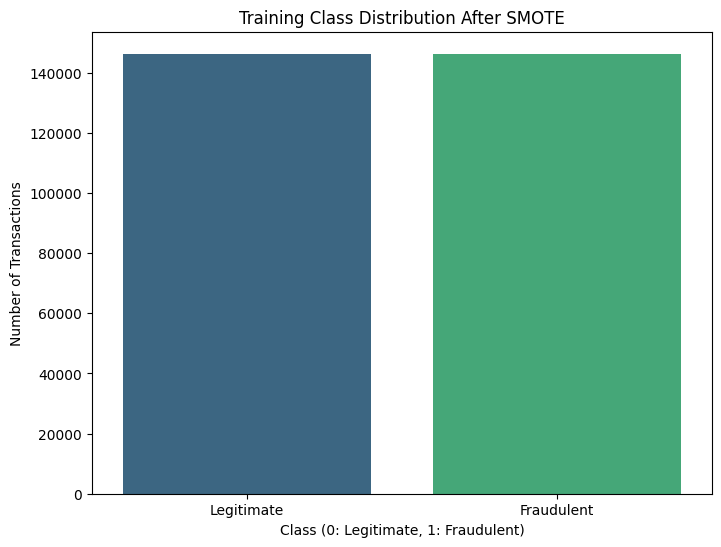

In [ ]:
# Re-run SMOTE application (cell_id: 23858814)
from imblearn.over_sampling import SMOTE

if 'X_train_processed' in locals() and 'y_train' in locals() and not X_train_processed.empty and not y_train.empty:
    print("Applying SMOTE to balance the training data...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

    print("SMOTE applied successfully.")
    print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
    print(f"Shape of y_train_resampled: {y_train_resampled.shape}")

    print("\nClass distribution after SMOTE:")
    print(y_train_resampled.value_counts())

    plt.figure(figsize=(8, 6))
    sns.countplot(x=y_train_resampled, palette='viridis')
    plt.title('Training Class Distribution After SMOTE')
    plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
    plt.ylabel('Number of Transactions')
    plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
    plt.show()
else:
    print("X_train_processed or y_train is not available or is empty. Cannot apply SMOTE.")


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve


models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}


trained_models = {}
model_performance = {}

print("Starting model training...")

if 'X_train_resampled' in locals() and 'y_train_resampled' in locals() and not X_train_resampled.empty:
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train_resampled, y_train_resampled)
        trained_models[name] = model
        print(f"{name} trained successfully.")


        y_pred = model.predict(X_test_processed)
        y_proba = model.predict_proba(X_test_processed)[:, 1]


        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        cm = confusion_matrix(y_test, y_pred)
        clf_report = classification_report(y_test, y_pred)

        model_performance[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'ROC-AUC': roc_auc,
            'Confusion Matrix': cm,
            'Classification Report': clf_report,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

        print(f"\n--- {name} Evaluation on Test Set ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", clf_report)
else:
    print("X_train_resampled or y_train_resampled is not available or is empty. Cannot train models.")


Starting model training...

Training Logistic Regression...
Logistic Regression trained successfully.

--- Logistic Regression Evaluation on Test Set ---
Accuracy: 0.8037
Precision: 0.0160
Recall: 0.7317
F1 Score: 0.0314
ROC-AUC: 0.8872
Confusion Matrix:
 [[118114  28798]
 [   172    469]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89    146912
           1       0.02      0.73      0.03       641

    accuracy                           0.80    147553
   macro avg       0.51      0.77      0.46    147553
weighted avg       0.99      0.80      0.89    147553


Training Decision Tree...
Decision Tree trained successfully.

--- Decision Tree Evaluation on Test Set ---
Accuracy: 0.9945
Precision: 0.4142
Recall: 0.6287
F1 Score: 0.4994
ROC-AUC: 0.8124
Confusion Matrix:
 [[146342    570]
 [   238    403]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00

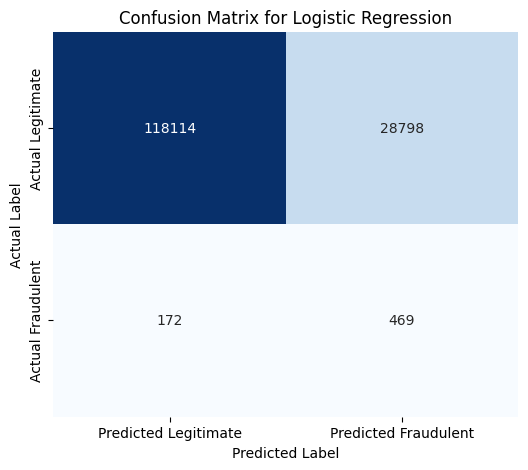

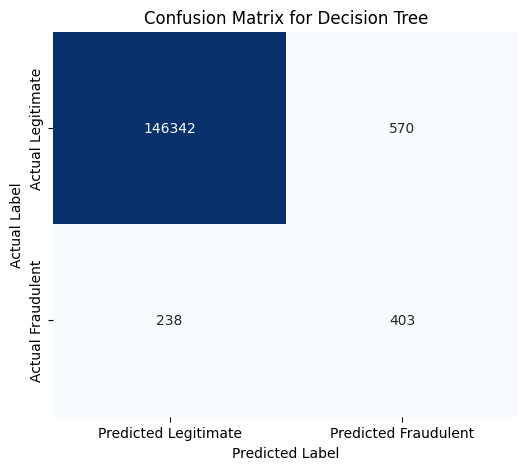

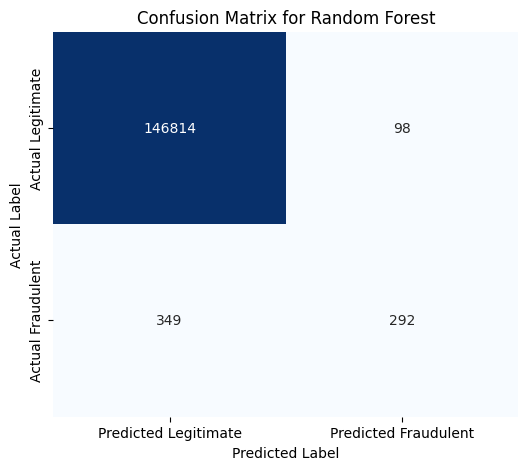

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

if model_performance:
    for name, metrics in model_performance.items():
        cm = metrics['Confusion Matrix']
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted Legitimate', 'Predicted Fraudulent'],
                    yticklabels=['Actual Legitimate', 'Actual Fraudulent'])
        plt.title(f'Confusion Matrix for {name}')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()
else:
    print("No model performance data available for confusion matrix visualization.")


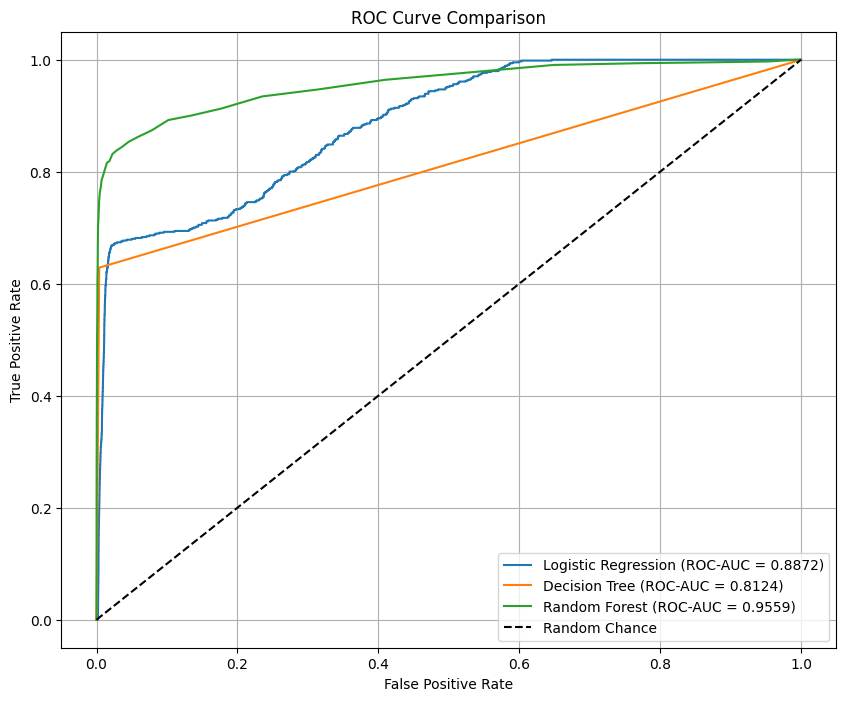

In [ ]:


if model_performance:
    plt.figure(figsize=(10, 8))
    for name, metrics in model_performance.items():
        fpr, tpr, _ = roc_curve(y_test, metrics['y_proba'])
        plt.plot(fpr, tpr, label=f'{name} (ROC-AUC = {metrics["ROC-AUC"]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No model performance data available for ROC curve comparison.")


/tmp/ipykernel_2343/802903392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')


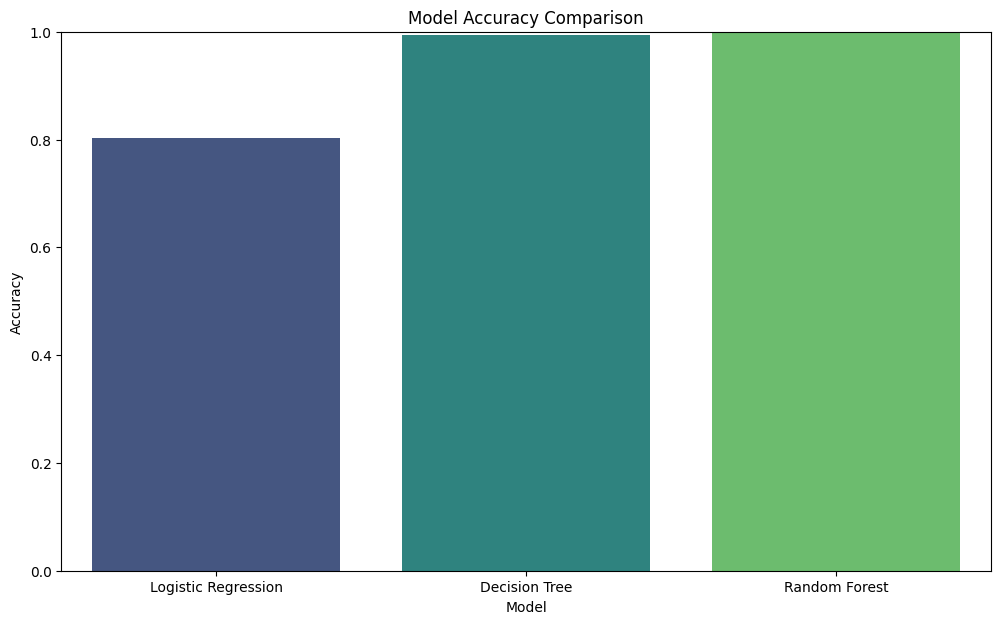

/tmp/ipykernel_2343/802903392.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['F1 Score'], palette='viridis')


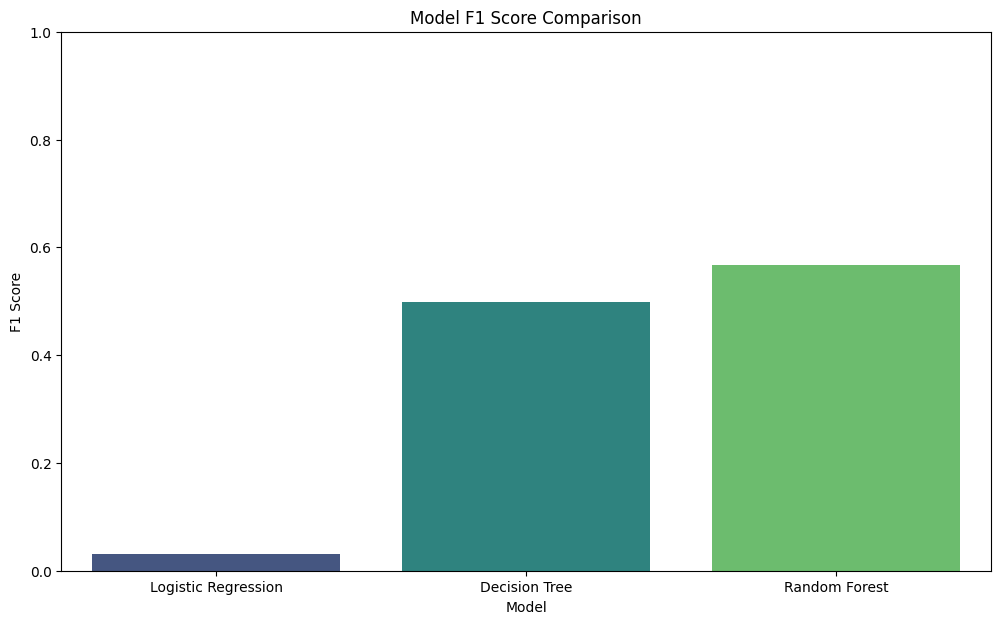

/tmp/ipykernel_2343/802903392.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['Recall'], palette='viridis')


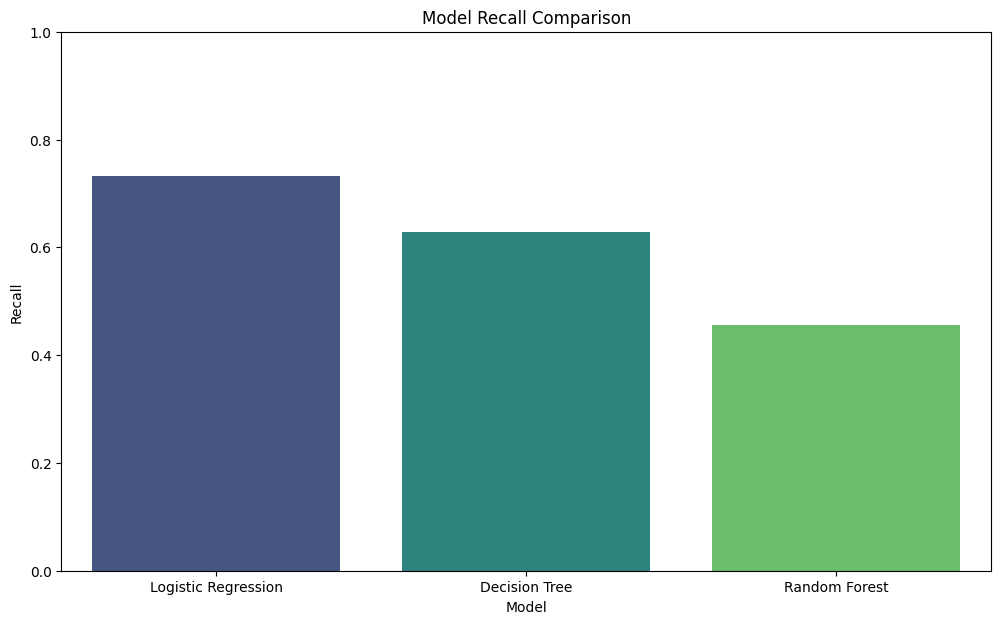

In [ ]:
# Re-run Model Accuracy Comparison Chart (cell_id: fa27b1cb)

if model_performance:
    metrics_df = pd.DataFrame.from_dict(model_performance, orient='index')

    plt.figure(figsize=(12, 7))
    sns.barplot(x=metrics_df.index, y=metrics_df['Accuracy'], palette='viridis')
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('Model')
    plt.ylim(0, 1)
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(x=metrics_df.index, y=metrics_df['F1 Score'], palette='viridis')
    plt.title('Model F1 Score Comparison')
    plt.ylabel('F1 Score')
    plt.xlabel('Model')
    plt.ylim(0, 1)
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(x=metrics_df.index, y=metrics_df['Recall'], palette='viridis')
    plt.title('Model Recall Comparison')
    plt.ylabel('Recall')
    plt.xlabel('Model')
    plt.ylim(0, 1)
    plt.show()
else:
    print("No model performance data available for comparison charts.")


/tmp/ipykernel_2343/1464829006.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=dt_feature_importance_df.head(15), palette='viridis')


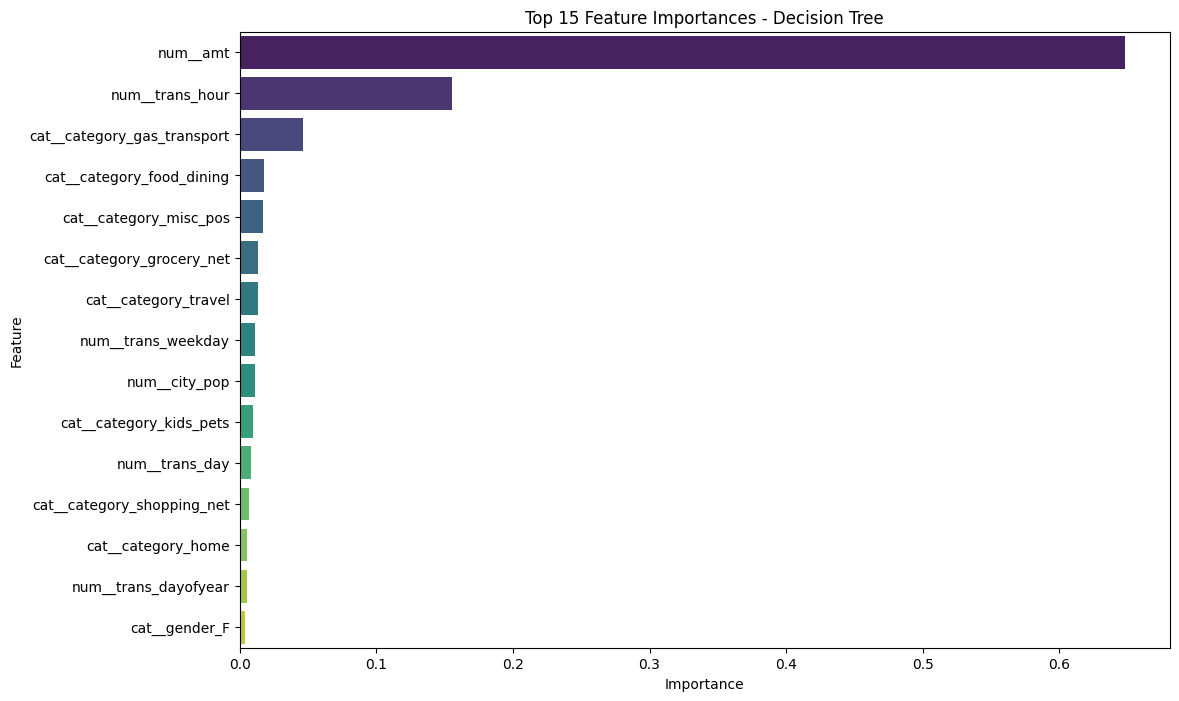

/tmp/ipykernel_2343/1464829006.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')


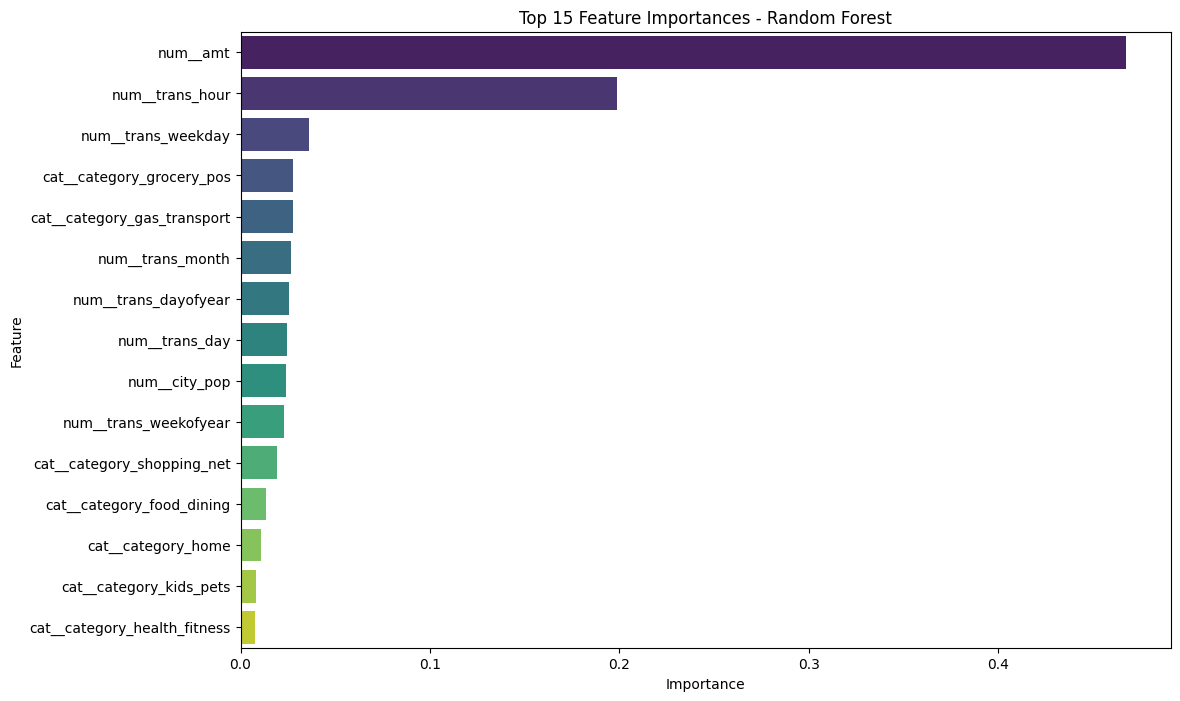

In [ ]:


if 'Decision Tree' in trained_models and hasattr(trained_models['Decision Tree'], 'feature_importances_') and X_train_resampled is not None:
    dt_importances = trained_models['Decision Tree'].feature_importances_
    feature_names = X_train_resampled.columns
    dt_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances})
    dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=dt_feature_importance_df.head(15), palette='viridis')
    plt.title('Top 15 Feature Importances - Decision Tree')
    plt.show()

if 'Random Forest' in trained_models and hasattr(trained_models['Random Forest'], 'feature_importances_') and X_train_resampled is not None:
    rf_importances = trained_models['Random Forest'].feature_importances_
    feature_names = X_train_resampled.columns
    rf_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
    rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df.head(15), palette='viridis')
    plt.title('Top 15 Feature Importances - Random Forest')
    plt.show()
else:
    print("Feature importance is not available for all trained tree-based models or models are not trained yet, or X_train_resampled is not available.")


### Feature Engineering: Extract Time-Based Features

In [ ]:

if 'trans_date_trans_time' in combined_df.columns:
    combined_df['trans_date_trans_time'] = pd.to_datetime(combined_df['trans_date_trans_time'], errors='coerce', format='mixed')

    combined_df['trans_hour'] = combined_df['trans_date_trans_time'].dt.hour
    combined_df['trans_day'] = combined_df['trans_date_trans_time'].dt.day
    combined_df['trans_month'] = combined_df['trans_date_trans_time'].dt.month
    combined_df['trans_weekday'] = combined_df['trans_date_trans_time'].dt.weekday
    combined_df['trans_dayofyear'] = combined_df['trans_date_trans_time'].dt.dayofyear
    combined_df['trans_weekofyear'] = combined_df['trans_date_trans_time'].dt.isocalendar().week.astype(int)


    combined_df = combined_df.drop(columns=['trans_date_trans_time', 'unix_time'], errors='ignore')
    print("Extracted time-based features and dropped original time columns.")
else:
    print("'trans_date_trans_time' column not found, skipping time-based feature engineering.")

print("\nCombined DataFrame after feature engineering:")
display(combined_df.head())

'trans_date_trans_time' column not found, skipping time-based feature engineering.

Combined DataFrame after feature engineering:


,category,is_test,city_pop,gender,amt,trans_hour,trans_day,trans_month,trans_weekday,trans_dayofyear,trans_weekofyear
0,misc_net,0,3495.0,F,4.97,0,1,1,1,1,1
1,grocery_pos,0,149.0,F,107.23,0,1,1,1,1,1
2,entertainment,0,4154.0,M,220.11,0,1,1,1,1,1
3,gas_transport,0,1939.0,M,45.00,0,1,1,1,1,1
4,misc_pos,0,99.0,M,41.96,0,1,1,1,1,1


### Encode Categorical Features and Scale Numerical Features using a Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


categorical_features = combined_df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_features = combined_df.select_dtypes(include=['number']).columns.tolist()


if 'is_test' in numerical_features:
    numerical_features.remove('is_test')


numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Preprocessing pipeline created successfully.")
print(f"Numerical features to scale: {numerical_features}")
print(f"Categorical features to encode: {categorical_features}")


combined_processed = preprocessing_pipeline.fit_transform(combined_df)


processed_feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()


combined_processed_df = pd.DataFrame(combined_processed, columns=processed_feature_names)

print("\nCombined data after preprocessing:")
display(combined_processed_df.head())
print(f"Shape of processed data: {combined_processed_df.shape}")


X_train_processed = combined_processed_df[combined_processed_df['preprocessor__is_test'] == 0].drop('preprocessor__is_test', axis=1)
X_test_processed = combined_processed_df[combined_processed_df['preprocessor__is_test'] == 1].drop('preprocessor__is_test', axis=1)

y_train = y_train.reset_index(drop=True).fillna(0).astype(int)
y_test = y_test.reset_index(drop=True).fillna(0).astype(int)

print("\nShape of X_train_processed:", X_train_processed.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test_processed:", X_test_processed.shape)
print("Shape of y_test:", y_test.shape)

Preprocessing pipeline created successfully.
Numerical features to scale: ['city_pop', 'amt', 'trans_hour', 'trans_day', 'trans_month', 'trans_weekday', 'trans_dayofyear', 'trans_weekofyear']
Categorical features to encode: ['category', 'gender']

Combined data after preprocessing:


,num__city_pop,num__amt,num__trans_hour,num__trans_day,num__trans_month,num__trans_weekday,num__trans_dayofyear,num__trans_weekofyear,cat__category_entertainment,cat__category_food_dining,...,cat__category_kids_pets,cat__category_misc_net,cat__category_misc_pos,cat__category_personal_care,cat__category_shopping_net,cat__category_shopping_pos,cat__category_travel,cat__gender_F,cat__gender_M,remainder__is_test
0,-0.283748,-0.428215,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.294824,0.239473,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.281566,0.976502,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.288898,-0.166847,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.294989,-0.186696,-1.876207,-1.557226,-1.320997,-0.819582,-1.484841,-1.45848,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Shape of processed data: (295170, 25)


KeyError: 'preprocessor__is_test'

In [ ]:
print("Hello")